In [297]:
%pip install pandas seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [298]:
import pandas as pd
import os, re, sys
import numpy as np

## List-to-method correspondences

In [299]:
def get_method_dict(file):
    method_dict = {'average' : 'average'}
    with open(file, 'r') as f:
        lines = [line.rstrip() for line in f.readlines()]
        i = 1
        for l in lines:
            match = re.search(r'^.+attrib=([^_]+)_mpd.+_thresh=([^_]+)_.+$', l)
            method = match.group(1)
            threshold = match.group(2)
            key = 'list' + str(i)
            method_dict[key] = method + '_' + threshold
            i += 1
    return method_dict


In [300]:
bcms_setimes_methods = get_method_dict('randomized_lists/randomized_lists.bcms_setimes.txt')
bcms_twitter_methods = get_method_dict('randomized_lists/randomized_lists.bcms_twitter.txt')
estonian_voro_methods = get_method_dict('randomized_lists/randomized_lists.estonian_voro.txt')
finnish_suomi24_methods = get_method_dict('randomized_lists/randomized_lists.finnish.txt')
german_jodel_methods = get_method_dict('randomized_lists/randomized_lists.jodel.txt')
greek_dialects_methods = get_method_dict('randomized_lists/randomized_lists.greek.txt')
scandinavian_slide_methods = get_method_dict('randomized_lists/randomized_lists.scandinavian.txt')

In [301]:
bcms_setimes_methods_df = pd.DataFrame.from_dict(bcms_setimes_methods, orient='index', columns=['method'])
bcms_setimes_methods_df

,method
average,average
list1,loo_0.6
list2,loo_0.1
list3,shap_0.6
list4,shap_0.1
list5,ig_0.1
list6,lime_0.6
list7,lime_0.1
list8,ig_0.6


In [302]:
bcms_twitter_methods_df = pd.DataFrame.from_dict(bcms_twitter_methods, orient='index', columns=['method'])
bcms_twitter_methods_df

,method
average,average
list1,lime_0.6
list2,loo_0.1
list3,shap_0.1
list4,ig_0.6
list5,loo_0.6
list6,ig_0.1
list7,shap_0.6
list8,lime_0.1


In [303]:
estonian_voro_methods_df = pd.DataFrame.from_dict(estonian_voro_methods, orient='index', columns=['method'])
estonian_voro_methods_df

,method
average,average
list1,ig_0.6
list2,ig_0.1
list3,loo_0.1
list4,shap_0.6
list5,shap_0.1
list6,loo_0.6
list7,lime_0.6
list8,lime_0.1


In [304]:
finnish_suomi24_methods_df = pd.DataFrame.from_dict(finnish_suomi24_methods, orient='index', columns=['method'])
finnish_suomi24_methods_df

,method
average,average
list1,shap_0.6
list2,loo_0.6
list3,ig_0.6
list4,loo_0.1
list5,lime_0.6
list6,lime_0.1
list7,ig_0.1
list8,shap_0.1


In [305]:
greek_dialects_methods_df = pd.DataFrame.from_dict(greek_dialects_methods, orient='index', columns=['method'])
greek_dialects_methods_df

,method
average,average
list1,ig_0.6
list2,shap_0.1
list3,loo_0.1
list4,loo_0.6
list5,shap_0.6
list6,ig_0.1
list7,lime_0.6
list8,lime_0.1


In [306]:
german_jodel_methods_df = pd.DataFrame.from_dict(german_jodel_methods, orient='index', columns=['method'])
german_jodel_methods_df

,method
average,average
list1,ig_0.1
list2,ig_0.6
list3,lime_0.1
list4,lime_0.6
list5,shap_0.6
list6,shap_0.1
list7,loo_0.1
list8,loo_0.6


In [307]:
scandinavian_slide_methods_df = pd.DataFrame.from_dict(scandinavian_slide_methods, orient='index', columns=['method'])
scandinavian_slide_methods_df

,method
average,average
list1,lime_0.1
list2,ig_0.1
list3,shap_0.1
list4,shap_0.6
list5,loo_0.1
list6,loo_0.6
list7,ig_0.6
list8,lime_0.6


## Importing all lists and labelling them with list ID

In [308]:
def make_dataset_df(folder):
    dfs = list()
    files = os.listdir(folder)
    for file in files:
        number = re.search(r'\d', file)
        if number:
            id = number.group()
        else:
            print("Skip file:", file)
            continue
        if file.endswith('.csv'):
            df = pd.read_csv(folder + '/' + file)
            df['file'] = "list" + id
            dfs.append(df)
        elif file.endswith('.txt'):
            df = pd.read_csv(folder + '/' + file, sep='\t')
            df['file'] = "list" + id
            dfs.append(df)
    full_df = pd.concat(dfs, ignore_index=True)
    return full_df

In [309]:
def get_number_annots(df):
    number_annots = df.value_counts('file').to_frame()
    number_annots = number_annots.rename(columns={number_annots.columns[0]: "total"})
    return number_annots

In [310]:
bcms_twitter_df = make_dataset_df('bcms_twitter')
bcms_twitter_df

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,file
0,😎🌞<unk>☕️🍉,bs,1.525842,0.104167,NaN,no,emoji,NaN,NaN,list6
1,☕️😎,bs,1.430635,0.104167,NaN,no,emoji,NaN,NaN,list6
2,unk>😏,bs,1.371145,0.104167,NaN,no,emoji,NaN,NaN,list6
3,🙈<unk>🙊,bs,1.352293,0.104167,NaN,no,emoji,NaN,NaN,list6
4,👍😏,bs,1.306748,0.104167,NaN,no,emoji,NaN,NaN,list6
...,...,...,...,...,...,...,...,...,...,...
3195,neizvesno,sr,0.611152,0.114583,NaN,yes,phon,NaN,NaN,list8
3196,osetiti,sr,0.610422,0.187500,NaN,yes,phon,NaN,NaN,list8
3197,pobedama,sr,0.608175,0.104167,NaN,yes,phon,NaN,NaN,list8
3198,miholjskoleto,sr,0.608170,0.104167,NaN,yes,phon,nonminimal,NaN,list8


In [311]:
bcms_setimes_df = make_dataset_df('bcms_setimes')
bcms_setimes_df

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,file
0,natjecateljskom,hr,0.241601,0.70,True,yes,lex,NaN,NaN,list6
1,liječniku,hr,0.232991,0.67,True,yes,lex,NaN,jek,list6
2,slijedili,hr,0.228810,0.69,True,no,phon,NaN,jek,list6
3,natjecalo,hr,0.221181,0.66,True,yes,lex,NaN,NaN,list6
4,strijelac,hr,0.211338,0.87,True,no,phon,NaN,jek,list6
...,...,...,...,...,...,...,...,...,...,...
1595,predsedavati,sr,0.362739,0.65,False,yes,phon,NaN,NaN,list8
1596,saopštavajući,sr,0.362684,0.92,False,yes,phon,NaN,NaN,list8
1597,evroatlantske,sr,0.362167,1.00,False,yes,phon,nonminimal,NaN,list8
1598,ignorisati,sr,0.361948,0.62,False,yes,morph-d,NaN,NaN,list8


In [312]:
estonian_voro_df = make_dataset_df('eesti-voro')
estonian_voro_df

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,file
0,jookseb,jooksma,ju̬u̬skma,est,x,NaN,NaN,NaN,NaN,NaN,NaN,list4
1,jooksis,jooksma,ju̬u̬skma,est,x,NaN,NaN,NaN,NaN,NaN,NaN,list4
2,veab,vedama,vidämä,est,xx,NaN,NaN,NaN,NaN,NaN,NaN,list4
3,tõmbab,tõmbama,tõ̭mbama,est,x,NaN,NaN,NaN,NaN,NaN,NaN,list4
4,õunad,õun,!=? upin,est,x,x,NaN,NaN,NaN,NaN,NaN,list4
...,...,...,...,...,...,...,...,...,...,...,...,...
1595,vöie,vüü,vöö,vro,x,NaN,NaN,NaN,NaN,NaN,NaN,list2
1596,käänüskõrd,käänüskõrd,!= paradigma,vro,NaN,x,NaN,NaN,NaN,NaN,NaN,list2
1597,sainapapõr,sainapapõŕ,!= tapeet,vro,NaN,x,NaN,NaN,NaN,NaN,NaN,list2
1598,paljodõn,palľo,palju,vro,x,NaN,NaN,NaN,NaN,NaN,NaN,list2


In [313]:
german_jodel_df = make_dataset_df('german_jodel')
german_jodel_df

Skip file: readme.txt


,token,label,score,selection_freq,code,other_variety,note,file
0,klagenfurt?🙈,AT,0.784082,0.10,NE,NaN,NaN,list6
1,flachwitzfreitag,AT,0.720582,0.98,unmarked,NaN,NaN,list6
2,salzburgring,AT,0.698946,0.10,NE,NaN,NaN,list6
3,österreichsollösterreichbleiben,AT,0.678802,0.10,NE,NaN,NaN,list6
4,körndln,AT,0.676768,0.10,morph,NaN,NaN,list6
...,...,...,...,...,...,...,...,...
3195,heinerfest,DE_S,0.313043,0.87,NE,NaN,NaN,list8
3196,ilmenau,DE_S,0.312112,1.00,NE,NaN,NaN,list8
3197,heimkommen,DE_S,0.312046,0.74,unmarked,NaN,NaN,list8
3198,passau,DE_S,0.312020,0.97,NE,NaN,NaN,list8


In [314]:
german_jodel_df['other_variety'].value_counts()

other_variety
yes    10
Yes     3
Name: count, dtype: int64

In [315]:
greek_dialects_df = make_dataset_df('greek_dialects')
greek_dialects_df

Skip file: OLD


,token,label,score,selection_freq,feature,file
0,τσίτα-να!-οψάργας,CRE,1.477226,0.10,Lex,list6
1,κι’αλλ’αγάπη,CRE,1.383781,0.10,Unmarked,list6
2,ν-αναστενάζεις,CRE,1.382307,0.10,Unmarked,list6
3,νταμπακοπαφλάγονας,CRE,1.368082,0.10,Unmarked,list6
4,τσ’αφανίσω»,CRE,1.327946,0.10,Morph,list6
...,...,...,...,...,...,...
3195,φρουροί,PON,0.373081,0.24,Unmarked,list8
3196,καρενέσε,PON,0.370964,0.10,Unmarked,list8
3197,μεξικού,PON,0.369579,0.96,NE,list8
3198,χλωρίζνε,PON,0.366267,0.10,Morph,list8


In [316]:
finnish_suomi24_df = make_dataset_df('finnish')
finnish_suomi24_df

,Unnamed: 0,token,label,score,selection_freq,category,lex_other_not,file
0,0,täötyy,east,0.863224,0.101010,phon,other,list8
1,1,pahimoelleen,east,0.847876,0.101010,phon,other,list8
2,2,sullakii,east,0.826737,0.202020,morph,other,list8
3,3,paekkaan,east,0.811686,0.101010,phon,other,list8
4,4,piästii,east,0.804127,0.101010,phon,other,list8
...,...,...,...,...,...,...,...,...
2015,295,varovainen,west,0.258827,0.101010,not,not,list7
2016,296,miä,west,0.258084,0.161616,lex,lex,list7
2017,297,nää,west,0.257057,0.191919,not,not,list7
2018,298,justihin,west,0.256982,0.222222,morph,other,list7


In [317]:
scandinavian_slide_df = make_dataset_df('scandinavian')
scandinavian_slide_df

Skip file: pyenv
Skip file: countBadEx.py
Skip file: scandinavian_unique_annotated.csv
Skip file: transferAnnotations.py
Skip file: orig
Skip file: countMainCategories.py
Skip file: evaluateLists.py
Skip file: namedEntities.py
Skip file: scandinavian_unique.txt


,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,file
0,0,ydmyghed,da,1.008674,0.10,False,NaN,ydmykhet,audmykt,ödmjukhet,False,False,True,True,False,False,False,False,True,list3
1,1,styrtregnede,da,1.000334,0.10,False,NaN,styrtregnet,styrtregna,NaN,False,False,True,False,False,False,False,False,True,list3
2,2,broderede,da,1.000113,0.10,False,NaN,broderte,NaN,broderade,False,False,True,False,False,False,False,False,True,list3
3,3,åbningsudsalg,da,0.999946,0.10,False,NaN,åpningssalg?,NaN,öppningsrea?,False,False,False,False,False,False,True,False,False,list3
4,4,orddelingsfejl,da,0.999925,0.10,False,NaN,orddelingsfeil,NaN,NaN,False,False,False,True,False,False,False,False,True,list3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,395,lämnade,sv,0.155722,0.98,False,efterlod,etterlot,NaN,NaN,False,False,False,False,False,False,True,False,False,list8
3196,396,färdiga,sv,0.154972,0.75,False,NaN,ferdige,ferdige,NaN,False,False,False,True,False,False,False,False,True,list8
3197,397,väntar,sv,0.154830,1.00,False,venter,venter,ventar,NaN,False,False,True,True,False,False,False,False,True,list8
3198,398,förändras,sv,0.154672,0.77,False,NaN,forandre,forandre,NaN,False,False,True,True,False,False,False,False,True,list8


# Data preparation

Aim: data frame containing the percentage of lexical shibboleths, other shibboleths, non shibboleths and if applicable other annotations

## Preparing bcms_setimes dataframe

In [318]:
number_annots = get_number_annots(bcms_setimes_df)
number_annots

,total
file,
list1,200
list2,200
list3,200
list4,200
list5,200
list6,200
list7,200
list8,200


In [319]:
bcms_setimes_shib_distro = bcms_setimes_df[(bcms_setimes_df['shibboleth'] == 'yes') & (bcms_setimes_df['feature'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
bcms_setimes_shib_distro['nonlex shib'] = bcms_setimes_df[(bcms_setimes_df['shibboleth'] == 'yes') & (bcms_setimes_df['feature'] != 'lex')].groupby('file').size()
bcms_setimes_shib_distro['non shib'] = bcms_setimes_df[bcms_setimes_df['shibboleth'] == 'no'].groupby('file').size()
bcms_setimes_shib_distro['rest'] = bcms_setimes_df[(bcms_setimes_df['shibboleth'] != 'no') & (bcms_setimes_df['shibboleth'] != 'yes')].groupby('file').size()
bcms_setimes_shib_distro = pd.concat([bcms_setimes_shib_distro, number_annots], axis=1)
bcms_setimes_shib_distro['shibboleths: lexical'] = round(bcms_setimes_shib_distro['lex shib'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['shibboleths: other'] = round(bcms_setimes_shib_distro['nonlex shib'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['non shibboleths'] = round(bcms_setimes_shib_distro['non shib'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['other'] = round(bcms_setimes_shib_distro['rest'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['perc sum'] = bcms_setimes_shib_distro['shibboleths: lexical'] + bcms_setimes_shib_distro['shibboleths: other'] \
+ bcms_setimes_shib_distro['non shibboleths'] + bcms_setimes_shib_distro['other']
bcms_setimes_shib_distro.loc['average'] = round(bcms_setimes_shib_distro.mean(axis=0), 1)
bcms_setimes_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
file,,,,,,,,,,
list1,33.0,70.0,94.0,3.0,200.0,16.5,35.0,47.0,1.5,100.0
list2,14.0,49.0,131.0,6.0,200.0,7.0,24.5,65.5,3.0,100.0
list3,33.0,72.0,95.0,NaN,200.0,16.5,36.0,47.5,NaN,NaN
list4,15.0,45.0,135.0,5.0,200.0,7.5,22.5,67.5,2.5,100.0
list5,20.0,58.0,120.0,2.0,200.0,10.0,29.0,60.0,1.0,100.0
list6,37.0,85.0,75.0,3.0,200.0,18.5,42.5,37.5,1.5,100.0
list7,22.0,88.0,82.0,8.0,200.0,11.0,44.0,41.0,4.0,100.0
list8,37.0,96.0,67.0,NaN,200.0,18.5,48.0,33.5,NaN,NaN
average,26.4,70.4,99.9,4.5,200.0,13.2,35.2,49.9,2.2,100.0


In [320]:
bcms_setimes_shib_distro = pd.concat([bcms_setimes_shib_distro, bcms_setimes_methods_df], axis=1)


In [321]:
bcms_setimes_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum,method
list1,33.0,70.0,94.0,3.0,200.0,16.5,35.0,47.0,1.5,100.0,loo_0.6
list2,14.0,49.0,131.0,6.0,200.0,7.0,24.5,65.5,3.0,100.0,loo_0.1
list3,33.0,72.0,95.0,NaN,200.0,16.5,36.0,47.5,NaN,NaN,shap_0.6
list4,15.0,45.0,135.0,5.0,200.0,7.5,22.5,67.5,2.5,100.0,shap_0.1
list5,20.0,58.0,120.0,2.0,200.0,10.0,29.0,60.0,1.0,100.0,ig_0.1
list6,37.0,85.0,75.0,3.0,200.0,18.5,42.5,37.5,1.5,100.0,lime_0.6
list7,22.0,88.0,82.0,8.0,200.0,11.0,44.0,41.0,4.0,100.0,lime_0.1
list8,37.0,96.0,67.0,NaN,200.0,18.5,48.0,33.5,NaN,NaN,ig_0.6
average,26.4,70.4,99.9,4.5,200.0,13.2,35.2,49.9,2.2,100.0,average


In [322]:
bcms_setimes_shib_distro = bcms_setimes_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
bcms_setimes_shib_distro

,list,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
method,,,,,,,,,,,
average,average,26.4,70.4,99.9,4.5,200.0,13.2,35.2,49.9,2.2,100.0
ig_0.1,list5,20.0,58.0,120.0,2.0,200.0,10.0,29.0,60.0,1.0,100.0
ig_0.6,list8,37.0,96.0,67.0,NaN,200.0,18.5,48.0,33.5,NaN,NaN
lime_0.1,list7,22.0,88.0,82.0,8.0,200.0,11.0,44.0,41.0,4.0,100.0
lime_0.6,list6,37.0,85.0,75.0,3.0,200.0,18.5,42.5,37.5,1.5,100.0
loo_0.1,list2,14.0,49.0,131.0,6.0,200.0,7.0,24.5,65.5,3.0,100.0
loo_0.6,list1,33.0,70.0,94.0,3.0,200.0,16.5,35.0,47.0,1.5,100.0
shap_0.1,list4,15.0,45.0,135.0,5.0,200.0,7.5,22.5,67.5,2.5,100.0
shap_0.6,list3,33.0,72.0,95.0,NaN,200.0,16.5,36.0,47.5,NaN,NaN


In [323]:
bcms_setimes_overview = bcms_setimes_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
bcms_setimes_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,13.2,35.2,49.9,2.2
ig_0.1,10.0,29.0,60.0,1.0
ig_0.6,18.5,48.0,33.5,NaN
lime_0.1,11.0,44.0,41.0,4.0
lime_0.6,18.5,42.5,37.5,1.5
loo_0.1,7.0,24.5,65.5,3.0
loo_0.6,16.5,35.0,47.0,1.5
shap_0.1,7.5,22.5,67.5,2.5
shap_0.6,16.5,36.0,47.5,NaN


## Preparing bcms_twitter dataset

In [324]:
number_annots = get_number_annots(bcms_twitter_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [325]:
bcms_twitter_shib_distro = bcms_twitter_df[(bcms_twitter_df['shibboleth'] == 'yes') & (bcms_twitter_df['feature'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
bcms_twitter_shib_distro['nonlex shib'] = bcms_twitter_df[(bcms_twitter_df['shibboleth'] == 'yes') & (bcms_twitter_df['feature'] != 'lex')].groupby('file').size()
bcms_twitter_shib_distro['non shib'] = bcms_twitter_df[bcms_twitter_df['shibboleth'] == 'no'].groupby('file').size()
bcms_twitter_shib_distro['rest'] = bcms_twitter_df[(bcms_twitter_df['shibboleth'] != 'no') & (bcms_twitter_df['shibboleth'] != 'yes')].groupby('file').size()
bcms_twitter_shib_distro = pd.concat([bcms_twitter_shib_distro, number_annots], axis=1)
bcms_twitter_shib_distro['shibboleths: lexical'] = round(bcms_twitter_shib_distro['lex shib'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['shibboleths: other'] = round(bcms_twitter_shib_distro['nonlex shib'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['non shibboleths'] = round(bcms_twitter_shib_distro['non shib'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['other'] = round(bcms_twitter_shib_distro['rest'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['perc sum'] = bcms_twitter_shib_distro['shibboleths: lexical'] + bcms_twitter_shib_distro['shibboleths: other'] \
+ bcms_twitter_shib_distro['non shibboleths'] + bcms_twitter_shib_distro['other']
bcms_twitter_shib_distro.loc['average'] = round(bcms_twitter_shib_distro.mean(axis=0), 1)
bcms_twitter_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
file,,,,,,,,,,
list1,15.0,109.0,268.0,8.0,400.0,3.8,27.3,67.0,2.0,100.1
list2,13.0,78.0,302.0,7.0,400.0,3.2,19.5,75.5,1.8,100.0
list3,19.0,100.0,273.0,8.0,400.0,4.8,25.0,68.2,2.0,100.0
list4,9.0,108.0,269.0,14.0,400.0,2.2,27.0,67.2,3.5,99.9
list5,9.0,97.0,284.0,10.0,400.0,2.2,24.2,71.0,2.5,99.9
list6,16.0,79.0,293.0,12.0,400.0,4.0,19.8,73.2,3.0,100.0
list7,16.0,112.0,262.0,10.0,400.0,4.0,28.0,65.5,2.5,100.0
list8,21.0,113.0,259.0,7.0,400.0,5.2,28.2,64.8,1.8,100.0
average,14.8,99.5,276.2,9.5,400.0,3.7,24.9,69.0,2.4,100.0


In [326]:
bcms_twitter_shib_distro = pd.concat([bcms_twitter_shib_distro, bcms_twitter_methods_df], axis = 1)
bcms_twitter_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum,method
list1,15.0,109.0,268.0,8.0,400.0,3.8,27.3,67.0,2.0,100.1,lime_0.6
list2,13.0,78.0,302.0,7.0,400.0,3.2,19.5,75.5,1.8,100.0,loo_0.1
list3,19.0,100.0,273.0,8.0,400.0,4.8,25.0,68.2,2.0,100.0,shap_0.1
list4,9.0,108.0,269.0,14.0,400.0,2.2,27.0,67.2,3.5,99.9,ig_0.6
list5,9.0,97.0,284.0,10.0,400.0,2.2,24.2,71.0,2.5,99.9,loo_0.6
list6,16.0,79.0,293.0,12.0,400.0,4.0,19.8,73.2,3.0,100.0,ig_0.1
list7,16.0,112.0,262.0,10.0,400.0,4.0,28.0,65.5,2.5,100.0,shap_0.6
list8,21.0,113.0,259.0,7.0,400.0,5.2,28.2,64.8,1.8,100.0,lime_0.1
average,14.8,99.5,276.2,9.5,400.0,3.7,24.9,69.0,2.4,100.0,average


In [327]:
bcms_twitter_shib_distro  = bcms_twitter_shib_distro.sort_values(by='method').reset_index(names=['list']).set_index('method')
bcms_twitter_shib_distro

,list,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
method,,,,,,,,,,,
average,average,14.8,99.5,276.2,9.5,400.0,3.7,24.9,69.0,2.4,100.0
ig_0.1,list6,16.0,79.0,293.0,12.0,400.0,4.0,19.8,73.2,3.0,100.0
ig_0.6,list4,9.0,108.0,269.0,14.0,400.0,2.2,27.0,67.2,3.5,99.9
lime_0.1,list8,21.0,113.0,259.0,7.0,400.0,5.2,28.2,64.8,1.8,100.0
lime_0.6,list1,15.0,109.0,268.0,8.0,400.0,3.8,27.3,67.0,2.0,100.1
loo_0.1,list2,13.0,78.0,302.0,7.0,400.0,3.2,19.5,75.5,1.8,100.0
loo_0.6,list5,9.0,97.0,284.0,10.0,400.0,2.2,24.2,71.0,2.5,99.9
shap_0.1,list3,19.0,100.0,273.0,8.0,400.0,4.8,25.0,68.2,2.0,100.0
shap_0.6,list7,16.0,112.0,262.0,10.0,400.0,4.0,28.0,65.5,2.5,100.0


In [328]:
bcms_twitter_overview = bcms_twitter_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
bcms_twitter_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,3.7,24.9,69.0,2.4
ig_0.1,4.0,19.8,73.2,3.0
ig_0.6,2.2,27.0,67.2,3.5
lime_0.1,5.2,28.2,64.8,1.8
lime_0.6,3.8,27.3,67.0,2.0
loo_0.1,3.2,19.5,75.5,1.8
loo_0.6,2.2,24.2,71.0,2.5
shap_0.1,4.8,25.0,68.2,2.0
shap_0.6,4.0,28.0,65.5,2.5


## Preparing german_jodel dataframe

In [329]:
number_annots = get_number_annots(german_jodel_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [330]:
german_jodel_df.value_counts('code')

code
NE          1982
unmarked     401
phon         346
lex          278
morph        187
spell          5
other          1
Name: count, dtype: int64

In [331]:
# Named entities are not shibboleths
# Only single-variety shibboleths count
german_jodel_df['shibboleth'] = 'no'
german_jodel_df.loc[(german_jodel_df['code'] != 'NE') & (german_jodel_df['code'] != 'unmarked') \
& (german_jodel_df['other_variety'].isna()) & (german_jodel_df['note'].isna()) , 'shibboleth'] = 'yes'
# sanity check:
german_jodel_df[(german_jodel_df['code'] == 'lex') & (german_jodel_df['shibboleth'] == 'no')]

,token,label,score,selection_freq,code,other_variety,note,file,shibboleth
469,gschwind,AT,0.439367,0.22,lex,NaN,not exclusive,list7,no
840,ausschaun,AT,0.238637,0.60,lex,NaN,not exclusive,list5,no
856,amal,AT,0.195144,0.99,lex,NaN,not exclusive,list5,no
857,schaun,AT,0.194866,1.00,lex,NaN,not exclusive,list5,no
868,schaut,AT,0.158346,1.00,lex,NaN,not exclusive,list5,no
869,heit,AT,0.155996,1.00,lex,NaN,not exclusive,list5,no
873,geschaut,AT,0.151669,0.75,lex,NaN,not exclusive,list5,no
1242,amal,AT,0.274777,1.00,lex,NaN,not exclusive,list4,no
1256,gscheit,AT,0.241944,0.63,lex,NaN,not exclusive,list4,no
1276,matura,AT,0.203438,0.85,lex,NaN,not exclusive,list4,no


In [332]:
german_jodel_shib_distro = german_jodel_df[(german_jodel_df['shibboleth'] == 'yes') & (german_jodel_df['code'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
german_jodel_shib_distro['nonlex shib'] = german_jodel_df[(german_jodel_df['shibboleth'] == 'yes') & (german_jodel_df['code'] != 'lex')].groupby('file').size()
german_jodel_shib_distro['non shib'] = german_jodel_df[german_jodel_df['shibboleth'] == 'no'].groupby('file').size()
german_jodel_shib_distro.loc[:,'sum'] = german_jodel_shib_distro.sum(axis=1)
german_jodel_shib_distro = pd.concat([german_jodel_shib_distro, number_annots], axis=1)
german_jodel_shib_distro['shibboleths: lexical'] = round(german_jodel_shib_distro['lex shib'] / german_jodel_shib_distro['total'] * 100, 1)
german_jodel_shib_distro['shibboleths: other'] = round(german_jodel_shib_distro['nonlex shib'] / german_jodel_shib_distro['total'] * 100, 1)
german_jodel_shib_distro['non shibboleths'] = round(german_jodel_shib_distro['non shib'] / german_jodel_shib_distro['total'] * 100, 1)
german_jodel_shib_distro['perc_sum'] = german_jodel_shib_distro['shibboleths: lexical'] + german_jodel_shib_distro['shibboleths: other'] + german_jodel_shib_distro['non shibboleths']
german_jodel_shib_distro.loc['average'] = round(german_jodel_shib_distro.mean(axis=0), 1)

german_jodel_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
file,,,,,,,,,
list1,57.0,54.0,289.0,400.0,400.0,14.2,13.5,72.2,99.9
list2,20.0,69.0,311.0,400.0,400.0,5.0,17.2,77.8,100.0
list3,44.0,57.0,299.0,400.0,400.0,11.0,14.2,74.8,100.0
list4,23.0,50.0,327.0,400.0,400.0,5.8,12.5,81.8,100.1
list5,19.0,59.0,322.0,400.0,400.0,4.8,14.8,80.5,100.1
list6,40.0,59.0,301.0,400.0,400.0,10.0,14.8,75.2,100.0
list7,29.0,60.0,311.0,400.0,400.0,7.2,15.0,77.8,100.0
list8,21.0,42.0,337.0,400.0,400.0,5.2,10.5,84.2,99.9
average,31.6,56.2,312.1,400.0,400.0,7.9,14.1,78.0,100.0


In [333]:
german_jodel_shib_distro = pd.concat([german_jodel_shib_distro, german_jodel_methods_df], axis=1)
german_jodel_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum,method
list1,57.0,54.0,289.0,400.0,400.0,14.2,13.5,72.2,99.9,ig_0.1
list2,20.0,69.0,311.0,400.0,400.0,5.0,17.2,77.8,100.0,ig_0.6
list3,44.0,57.0,299.0,400.0,400.0,11.0,14.2,74.8,100.0,lime_0.1
list4,23.0,50.0,327.0,400.0,400.0,5.8,12.5,81.8,100.1,lime_0.6
list5,19.0,59.0,322.0,400.0,400.0,4.8,14.8,80.5,100.1,shap_0.6
list6,40.0,59.0,301.0,400.0,400.0,10.0,14.8,75.2,100.0,shap_0.1
list7,29.0,60.0,311.0,400.0,400.0,7.2,15.0,77.8,100.0,loo_0.1
list8,21.0,42.0,337.0,400.0,400.0,5.2,10.5,84.2,99.9,loo_0.6
average,31.6,56.2,312.1,400.0,400.0,7.9,14.1,78.0,100.0,average


In [334]:
german_jodel_shib_distro = german_jodel_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
german_jodel_shib_distro

,list,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
method,,,,,,,,,,
average,average,31.6,56.2,312.1,400.0,400.0,7.9,14.1,78.0,100.0
ig_0.1,list1,57.0,54.0,289.0,400.0,400.0,14.2,13.5,72.2,99.9
ig_0.6,list2,20.0,69.0,311.0,400.0,400.0,5.0,17.2,77.8,100.0
lime_0.1,list3,44.0,57.0,299.0,400.0,400.0,11.0,14.2,74.8,100.0
lime_0.6,list4,23.0,50.0,327.0,400.0,400.0,5.8,12.5,81.8,100.1
loo_0.1,list7,29.0,60.0,311.0,400.0,400.0,7.2,15.0,77.8,100.0
loo_0.6,list8,21.0,42.0,337.0,400.0,400.0,5.2,10.5,84.2,99.9
shap_0.1,list6,40.0,59.0,301.0,400.0,400.0,10.0,14.8,75.2,100.0
shap_0.6,list5,19.0,59.0,322.0,400.0,400.0,4.8,14.8,80.5,100.1


In [335]:
german_jodel_overview = german_jodel_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']]
german_jodel_overview

,shibboleths: lexical,shibboleths: other,non shibboleths
method,,,
average,7.9,14.1,78.0
ig_0.1,14.2,13.5,72.2
ig_0.6,5.0,17.2,77.8
lime_0.1,11.0,14.2,74.8
lime_0.6,5.8,12.5,81.8
loo_0.1,7.2,15.0,77.8
loo_0.6,5.2,10.5,84.2
shap_0.1,10.0,14.8,75.2
shap_0.6,4.8,14.8,80.5


## Preparing greek_dialects dataframe

In [336]:
greek_dialects_df[greek_dialects_df['file'] ==  'list2']

,token,label,score,selection_freq,feature,file
2400,θυμάται_στο,CRE,1.024675,0.10,Unmarked,list2
2401,μετακινήσω,CRE,1.009906,0.10,Unmarked,list2
2402,ακροατή/αναγνώστη,CRE,1.003343,0.10,Unmarked,list2
2403,ξεφωνήση,CRE,0.999911,0.10,Morph,list2
2404,ξεπρήσθη,CRE,0.999860,0.10,Morph,list2
...,...,...,...,...,...,...
2795,τιούτσεβα,PON,0.213957,0.25,NE,list2
2796,επεστάθεν,PON,0.212394,0.34,Lex,list2
2797,ασατήν,PON,0.212127,0.10,Lex,list2
2798,οροπέδιο,PON,0.211999,0.10,Unmarked,list2


In [337]:
greek_dialects_df.value_counts('feature')

feature
Unmarked    1516
Phon         604
NE           420
Lex          342
Morph        312
Other          3
I              1
Spell          1
ΝΕ             1
Name: count, dtype: int64

In [338]:
number_annots = get_number_annots(greek_dialects_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [339]:
greek_dialects_shib_distro = greek_dialects_df[greek_dialects_df['feature'] == 'Lex'].groupby('file').size().to_frame(name='lex shib')
greek_dialects_shib_distro['nonlex shib'] = greek_dialects_df[(greek_dialects_df['feature'] != 'NE') & (greek_dialects_df['feature'] != 'Unmarked') & (greek_dialects_df['feature'] != 'Lex')].groupby('file').size()
greek_dialects_shib_distro['non shib'] = greek_dialects_df[(greek_dialects_df['feature'] == 'NE') | (greek_dialects_df['feature'] == 'Unmarked')].groupby('file').size()
greek_dialects_shib_distro.loc[:, 'sum'] = greek_dialects_shib_distro.sum(axis=1)
greek_dialects_shib_distro = pd.concat([greek_dialects_shib_distro, number_annots], axis=1)
greek_dialects_shib_distro['shibboleths: lexical'] = round(greek_dialects_shib_distro['lex shib'] / \
                                                          greek_dialects_shib_distro['total'] * 100, 1)
greek_dialects_shib_distro['shibboleths: other'] = round(greek_dialects_shib_distro['nonlex shib'] / \
                                                          greek_dialects_shib_distro['total'] * 100, 1)
greek_dialects_shib_distro['non shibboleths'] = round(greek_dialects_shib_distro['non shib'] / \
                                                          greek_dialects_shib_distro['total'] * 100, 1)
greek_dialects_shib_distro['perc_sum'] = greek_dialects_shib_distro['shibboleths: lexical'] + greek_dialects_shib_distro['shibboleths: other'] \
+ greek_dialects_shib_distro['non shibboleths']
greek_dialects_shib_distro.loc['average'] = round(greek_dialects_shib_distro.mean(axis=0) , 1)

greek_dialects_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
file,,,,,,,,,
list1,74.0,164.0,162.0,400.0,400.0,18.5,41.0,40.5,100.0
list2,38.0,122.0,240.0,400.0,400.0,9.5,30.5,60.0,100.0
list3,25.0,80.0,295.0,400.0,400.0,6.2,20.0,73.8,100.0
list4,30.0,72.0,298.0,400.0,400.0,7.5,18.0,74.5,100.0
list5,30.0,154.0,216.0,400.0,400.0,7.5,38.5,54.0,100.0
list6,72.0,108.0,220.0,400.0,400.0,18.0,27.0,55.0,100.0
list7,31.0,94.0,275.0,400.0,400.0,7.8,23.5,68.8,100.1
list8,42.0,128.0,230.0,400.0,400.0,10.5,32.0,57.5,100.0
average,42.8,115.2,242.0,400.0,400.0,10.7,28.8,60.5,100.0


In [340]:
greek_dialects_shib_distro = pd.concat([greek_dialects_shib_distro, greek_dialects_methods_df], axis=1)
greek_dialects_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum,method
list1,74.0,164.0,162.0,400.0,400.0,18.5,41.0,40.5,100.0,ig_0.6
list2,38.0,122.0,240.0,400.0,400.0,9.5,30.5,60.0,100.0,shap_0.1
list3,25.0,80.0,295.0,400.0,400.0,6.2,20.0,73.8,100.0,loo_0.1
list4,30.0,72.0,298.0,400.0,400.0,7.5,18.0,74.5,100.0,loo_0.6
list5,30.0,154.0,216.0,400.0,400.0,7.5,38.5,54.0,100.0,shap_0.6
list6,72.0,108.0,220.0,400.0,400.0,18.0,27.0,55.0,100.0,ig_0.1
list7,31.0,94.0,275.0,400.0,400.0,7.8,23.5,68.8,100.1,lime_0.6
list8,42.0,128.0,230.0,400.0,400.0,10.5,32.0,57.5,100.0,lime_0.1
average,42.8,115.2,242.0,400.0,400.0,10.7,28.8,60.5,100.0,average


In [341]:
greek_dialects_shib_distro = greek_dialects_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
greek_dialects_shib_distro

,list,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
method,,,,,,,,,,
average,average,42.8,115.2,242.0,400.0,400.0,10.7,28.8,60.5,100.0
ig_0.1,list6,72.0,108.0,220.0,400.0,400.0,18.0,27.0,55.0,100.0
ig_0.6,list1,74.0,164.0,162.0,400.0,400.0,18.5,41.0,40.5,100.0
lime_0.1,list8,42.0,128.0,230.0,400.0,400.0,10.5,32.0,57.5,100.0
lime_0.6,list7,31.0,94.0,275.0,400.0,400.0,7.8,23.5,68.8,100.1
loo_0.1,list3,25.0,80.0,295.0,400.0,400.0,6.2,20.0,73.8,100.0
loo_0.6,list4,30.0,72.0,298.0,400.0,400.0,7.5,18.0,74.5,100.0
shap_0.1,list2,38.0,122.0,240.0,400.0,400.0,9.5,30.5,60.0,100.0
shap_0.6,list5,30.0,154.0,216.0,400.0,400.0,7.5,38.5,54.0,100.0


In [342]:
greek_dialects_overview = greek_dialects_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']]
greek_dialects_overview

,shibboleths: lexical,shibboleths: other,non shibboleths
method,,,
average,10.7,28.8,60.5
ig_0.1,18.0,27.0,55.0
ig_0.6,18.5,41.0,40.5
lime_0.1,10.5,32.0,57.5
lime_0.6,7.8,23.5,68.8
loo_0.1,6.2,20.0,73.8
loo_0.6,7.5,18.0,74.5
shap_0.1,9.5,30.5,60.0
shap_0.6,7.5,38.5,54.0


## Preparing finnish_suomi24 dataframe

In [343]:
finnish_suomi24_df

,Unnamed: 0,token,label,score,selection_freq,category,lex_other_not,file
0,0,täötyy,east,0.863224,0.101010,phon,other,list8
1,1,pahimoelleen,east,0.847876,0.101010,phon,other,list8
2,2,sullakii,east,0.826737,0.202020,morph,other,list8
3,3,paekkaan,east,0.811686,0.101010,phon,other,list8
4,4,piästii,east,0.804127,0.101010,phon,other,list8
...,...,...,...,...,...,...,...,...
2015,295,varovainen,west,0.258827,0.101010,not,not,list7
2016,296,miä,west,0.258084,0.161616,lex,lex,list7
2017,297,nää,west,0.257057,0.191919,not,not,list7
2018,298,justihin,west,0.256982,0.222222,morph,other,list7


In [344]:
finnish_suomi24_df.value_counts('label')

label
north    680
east     673
west     667
Name: count, dtype: int64

In [345]:
number_annots = get_number_annots(finnish_suomi24_df)
number_annots

,total
file,
list4,300
list6,300
list7,300
list8,300
list5,221
list2,207
list1,206
list3,186


In [346]:
finnish_suomi24_shib_distro = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] == 'lex'].groupby('file').size().to_frame(name='lex shib')
finnish_suomi24_shib_distro['nonlex shib'] = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] == 'other'].groupby('file').size()
finnish_suomi24_shib_distro['non shib'] = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] ==  'not'].groupby('file').size()
finnish_suomi24_shib_distro.loc[:, 'sum'] = finnish_suomi24_shib_distro.sum(axis=1)
finnish_suomi24_shib_distro = pd.concat([finnish_suomi24_shib_distro, number_annots], axis=1)
finnish_suomi24_shib_distro['shibboleths: lexical'] = round(finnish_suomi24_shib_distro['lex shib'] / 
                                                             finnish_suomi24_shib_distro['total'] * 100, 1)
finnish_suomi24_shib_distro['shibboleths: other'] = round(finnish_suomi24_shib_distro['nonlex shib'] / 
                                                             finnish_suomi24_shib_distro['total'] * 100, 1)
finnish_suomi24_shib_distro['non shibboleths'] = round(finnish_suomi24_shib_distro['non shib'] / 
                                                             finnish_suomi24_shib_distro['total'] * 100, 1)
finnish_suomi24_shib_distro['perc_sum'] = finnish_suomi24_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']].sum(axis=1)
finnish_suomi24_shib_distro.loc['average'] = round(finnish_suomi24_shib_distro.mean(axis=0), 1)


finnish_suomi24_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
file,,,,,,,,,
list1,19.0,49.0,138.0,206.0,206.0,9.2,23.8,67.0,100.0
list2,21.0,44.0,142.0,207.0,207.0,10.1,21.3,68.6,100.0
list3,19.0,42.0,125.0,186.0,186.0,10.2,22.6,67.2,100.0
list4,17.0,196.0,87.0,300.0,300.0,5.7,65.3,29.0,100.0
list5,21.0,55.0,145.0,221.0,221.0,9.5,24.9,65.6,100.0
list6,21.0,201.0,78.0,300.0,300.0,7.0,67.0,26.0,100.0
list7,9.0,186.0,105.0,300.0,300.0,3.0,62.0,35.0,100.0
list8,16.0,206.0,78.0,300.0,300.0,5.3,68.7,26.0,100.0
average,17.9,122.4,112.2,252.5,252.5,7.5,44.4,48.0,100.0


In [347]:
finnish_suomi24_shib_distro = pd.concat([finnish_suomi24_shib_distro, finnish_suomi24_methods_df], axis=1)
finnish_suomi24_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum,method
list1,19.0,49.0,138.0,206.0,206.0,9.2,23.8,67.0,100.0,shap_0.6
list2,21.0,44.0,142.0,207.0,207.0,10.1,21.3,68.6,100.0,loo_0.6
list3,19.0,42.0,125.0,186.0,186.0,10.2,22.6,67.2,100.0,ig_0.6
list4,17.0,196.0,87.0,300.0,300.0,5.7,65.3,29.0,100.0,loo_0.1
list5,21.0,55.0,145.0,221.0,221.0,9.5,24.9,65.6,100.0,lime_0.6
list6,21.0,201.0,78.0,300.0,300.0,7.0,67.0,26.0,100.0,lime_0.1
list7,9.0,186.0,105.0,300.0,300.0,3.0,62.0,35.0,100.0,ig_0.1
list8,16.0,206.0,78.0,300.0,300.0,5.3,68.7,26.0,100.0,shap_0.1
average,17.9,122.4,112.2,252.5,252.5,7.5,44.4,48.0,100.0,average


In [348]:
finnish_suomi24_shib_distro = finnish_suomi24_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
finnish_suomi24_shib_distro

,list,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
method,,,,,,,,,,
average,average,17.9,122.4,112.2,252.5,252.5,7.5,44.4,48.0,100.0
ig_0.1,list7,9.0,186.0,105.0,300.0,300.0,3.0,62.0,35.0,100.0
ig_0.6,list3,19.0,42.0,125.0,186.0,186.0,10.2,22.6,67.2,100.0
lime_0.1,list6,21.0,201.0,78.0,300.0,300.0,7.0,67.0,26.0,100.0
lime_0.6,list5,21.0,55.0,145.0,221.0,221.0,9.5,24.9,65.6,100.0
loo_0.1,list4,17.0,196.0,87.0,300.0,300.0,5.7,65.3,29.0,100.0
loo_0.6,list2,21.0,44.0,142.0,207.0,207.0,10.1,21.3,68.6,100.0
shap_0.1,list8,16.0,206.0,78.0,300.0,300.0,5.3,68.7,26.0,100.0
shap_0.6,list1,19.0,49.0,138.0,206.0,206.0,9.2,23.8,67.0,100.0


In [349]:
finnish_suomi24_overview = finnish_suomi24_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']]
finnish_suomi24_overview

,shibboleths: lexical,shibboleths: other,non shibboleths
method,,,
average,7.5,44.4,48.0
ig_0.1,3.0,62.0,35.0
ig_0.6,10.2,22.6,67.2
lime_0.1,7.0,67.0,26.0
lime_0.6,9.5,24.9,65.6
loo_0.1,5.7,65.3,29.0
loo_0.6,10.1,21.3,68.6
shap_0.1,5.3,68.7,26.0
shap_0.6,9.2,23.8,67.0


## Prepare estonian-voro dataframe

In [350]:
estonian_voro_df

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,file
0,jookseb,jooksma,ju̬u̬skma,est,x,NaN,NaN,NaN,NaN,NaN,NaN,list4
1,jooksis,jooksma,ju̬u̬skma,est,x,NaN,NaN,NaN,NaN,NaN,NaN,list4
2,veab,vedama,vidämä,est,xx,NaN,NaN,NaN,NaN,NaN,NaN,list4
3,tõmbab,tõmbama,tõ̭mbama,est,x,NaN,NaN,NaN,NaN,NaN,NaN,list4
4,õunad,õun,!=? upin,est,x,x,NaN,NaN,NaN,NaN,NaN,list4
...,...,...,...,...,...,...,...,...,...,...,...,...
1595,vöie,vüü,vöö,vro,x,NaN,NaN,NaN,NaN,NaN,NaN,list2
1596,käänüskõrd,käänüskõrd,!= paradigma,vro,NaN,x,NaN,NaN,NaN,NaN,NaN,list2
1597,sainapapõr,sainapapõŕ,!= tapeet,vro,NaN,x,NaN,NaN,NaN,NaN,NaN,list2
1598,paljodõn,palľo,palju,vro,x,NaN,NaN,NaN,NaN,NaN,NaN,list2


In [351]:
number_annots = get_number_annots(estonian_voro_df)
number_annots

,total
file,
list1,200
list2,200
list3,200
list4,200
list5,200
list6,200
list7,200
list8,200


In [352]:
estonian_voro_df[estonian_voro_df['Lexicon'].str.contains(r'x|\?', na=False)]

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,file
4,õunad,õun,!=? upin,est,x,x,NaN,NaN,NaN,NaN,NaN,list4
8,tõusis,tõusma,!= nõsõma,est,NaN,x,NaN,NaN,NaN,NaN,NaN,list4
9,tõuseb,tõusma,!= nõsõma,est,x,x,NaN,NaN,NaN,NaN,NaN,list4
11,vaikselt,vaikselt,!= vaikligult,est,x,x,NaN,NaN,NaN,NaN,derivation,list4
24,kiiremini,kiiremini,!= kipõmbahe,est,NaN,x,NaN,NaN,NaN,NaN,NaN,list4
...,...,...,...,...,...,...,...,...,...,...,...,...
1584,korgõrõuhkus,korgõrõuhkus,!=? kõrgrõhk,vro,NaN,x,NaN,NaN,NaN,NaN,NaN,list2
1589,teedüstahvli,teedüstahvli (= teedüssetahvli?),(teadetetahvel?),vro,NaN,x,NaN,NaN,NaN,NaN,derivation,list2
1593,valmispannusõgaq,valmispannus,!= preparaat (a different dictionary also know...,vro,NaN,x,NaN,NaN,NaN,NaN,derivation,list2
1596,käänüskõrd,käänüskõrd,!= paradigma,vro,NaN,x,NaN,NaN,NaN,NaN,NaN,list2


In [353]:
estonian_voro_df["unk"] = 0
estonian_voro_df.loc[(estonian_voro_df['Unknown'].str.contains('x', na=False) | estonian_voro_df['Other'].str.contains('x', na=False)), "unk"] = 1
estonian_voro_df["noshib"] = 0
estonian_voro_df.loc[((estonian_voro_df["unk"] == 0) & estonian_voro_df['Unmarked'].str.contains('x', na=False)), "noshib"] = 1
estonian_voro_df["lexshib"] = 0
estonian_voro_df.loc[((estonian_voro_df["unk"] == 0) & (estonian_voro_df["noshib"] == 0) & estonian_voro_df['Lexicon'].str.contains('x', na=False)), "lexshib"] = 1
estonian_voro_df["nonlexshib"] = 0
estonian_voro_df.loc[((estonian_voro_df["unk"] == 0) & (estonian_voro_df["noshib"] == 0) & (estonian_voro_df["lexshib"] == 0) & estonian_voro_df['Phon-Morph-infl-Morph-der-Spelling'].str.contains(r'x|s', na=False)), "nonlexshib"] = 1

estonian_voro_df.loc[estonian_voro_df["unk"] + estonian_voro_df["noshib"] + estonian_voro_df["lexshib"] + estonian_voro_df["nonlexshib"] == 0, "unk"] += 1

estonian_voro_df[estonian_voro_df["unk"] >= 1]

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,file,unk,noshib,lexshib,nonlexshib
107,nal,? tokenisation mistakenly splitting nal´alt?,?,vro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list4,1,0,0,0
206,kaebu,kaebu(-punn),"kitupunn, kaivatś",est,NaN,x,NaN,x,NaN,NaN,tokenisation problem,list3,1,0,0,0
267,se,?,?,est,NaN,NaN,NaN,x,NaN,NaN,virhe,list3,1,0,0,0
298,edas,edas-,iin-,est,x,NaN,NaN,x,NaN,NaN,tokenisation problem,list3,1,0,0,0
301,passmisõst,?,?,vro,x,NaN,NaN,NaN,NaN,x,NaN,list3,1,0,0,0
321,innõ,ynnõ,ainult,vro,x,x,NaN,NaN,NaN,x,NaN,list3,1,0,0,0
356,mustasitikõ,?,?,vro,x,NaN,NaN,NaN,NaN,x,NaN,list3,1,0,0,0
364,ülekuvvõkümne,ülekuvvõkümne,üle kuuekümne,vro,x,NaN,NaN,x,NaN,NaN,virhe?,list3,1,0,0,0
392,hinnästilmarahva,hinnäst ilmarahvas,ennast != külä-/linnarahvas,vro,NaN,x,NaN,x,NaN,NaN,"virhe? ehkä ""hinnäst ilmarahva""",list3,1,0,0,0
473,pandi,panema,pandma,est,NaN,NaN,NaN,x,NaN,NaN,NaN,list7,1,0,0,0


In [354]:
estonian_voro_shib_distro = estonian_voro_df[estonian_voro_df['lexshib']==1].groupby('file').size().to_frame(name="lex shib")
estonian_voro_shib_distro['non lex shib'] = estonian_voro_df[estonian_voro_df['nonlexshib']==1].groupby('file').size()
estonian_voro_shib_distro['non shib'] = estonian_voro_df[estonian_voro_df['noshib']==1].groupby('file').size()
estonian_voro_shib_distro['rest'] = estonian_voro_df[estonian_voro_df['unk']==1].groupby('file').size()
estonian_voro_shib_distro.loc[:, 'sum'] = estonian_voro_shib_distro.sum(axis=1)

estonian_voro_shib_distro = pd.concat([estonian_voro_shib_distro, number_annots], axis=1)
estonian_voro_shib_distro['shibboleths: lexical'] = round(estonian_voro_shib_distro['lex shib'] \
                                                               / estonian_voro_shib_distro['total'] * 100, 1)
estonian_voro_shib_distro['shibboleths: other'] = round(estonian_voro_shib_distro['non lex shib'] \
                                                               / estonian_voro_shib_distro['total'] * 100, 1)
estonian_voro_shib_distro['non shibboleths'] = round(estonian_voro_shib_distro['non shib'] \
                                                               / estonian_voro_shib_distro['total'] * 100, 1)
estonian_voro_shib_distro['other'] = round(estonian_voro_shib_distro['rest'] \
                                                               / estonian_voro_shib_distro['total'] * 100, 1)

estonian_voro_shib_distro.loc[:, 'perc_sum'] = estonian_voro_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']].sum(axis=1)
estonian_voro_shib_distro.loc['average'] = round(estonian_voro_shib_distro.mean(axis=0), 1)

estonian_voro_shib_distro

,lex shib,non lex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum
file,,,,,,,,,,,
list1,35.0,147.0,16.0,2.0,200.0,200.0,17.5,73.5,8.0,1.0,100.0
list2,72.0,114.0,7.0,7.0,200.0,200.0,36.0,57.0,3.5,3.5,100.0
list3,52.0,133.0,7.0,8.0,200.0,200.0,26.0,66.5,3.5,4.0,100.0
list4,22.0,153.0,24.0,1.0,200.0,200.0,11.0,76.5,12.0,0.5,100.0
list5,54.0,136.0,4.0,6.0,200.0,200.0,27.0,68.0,2.0,3.0,100.0
list6,18.0,141.0,39.0,2.0,200.0,200.0,9.0,70.5,19.5,1.0,100.0
list7,17.0,140.0,42.0,1.0,200.0,200.0,8.5,70.0,21.0,0.5,100.0
list8,55.0,134.0,2.0,9.0,200.0,200.0,27.5,67.0,1.0,4.5,100.0
average,40.6,137.2,17.6,4.5,200.0,200.0,20.3,68.6,8.8,2.2,100.0


In [355]:
estonian_voro_shib_distro = pd.concat([estonian_voro_shib_distro, estonian_voro_methods_df], axis=1)
estonian_voro_shib_distro

,lex shib,non lex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum,method
list1,35.0,147.0,16.0,2.0,200.0,200.0,17.5,73.5,8.0,1.0,100.0,ig_0.6
list2,72.0,114.0,7.0,7.0,200.0,200.0,36.0,57.0,3.5,3.5,100.0,ig_0.1
list3,52.0,133.0,7.0,8.0,200.0,200.0,26.0,66.5,3.5,4.0,100.0,loo_0.1
list4,22.0,153.0,24.0,1.0,200.0,200.0,11.0,76.5,12.0,0.5,100.0,shap_0.6
list5,54.0,136.0,4.0,6.0,200.0,200.0,27.0,68.0,2.0,3.0,100.0,shap_0.1
list6,18.0,141.0,39.0,2.0,200.0,200.0,9.0,70.5,19.5,1.0,100.0,loo_0.6
list7,17.0,140.0,42.0,1.0,200.0,200.0,8.5,70.0,21.0,0.5,100.0,lime_0.6
list8,55.0,134.0,2.0,9.0,200.0,200.0,27.5,67.0,1.0,4.5,100.0,lime_0.1
average,40.6,137.2,17.6,4.5,200.0,200.0,20.3,68.6,8.8,2.2,100.0,average


In [356]:
estonian_voro_shib_distro = estonian_voro_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
estonian_voro_shib_distro

,list,lex shib,non lex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum
method,,,,,,,,,,,,
average,average,40.6,137.2,17.6,4.5,200.0,200.0,20.3,68.6,8.8,2.2,100.0
ig_0.1,list2,72.0,114.0,7.0,7.0,200.0,200.0,36.0,57.0,3.5,3.5,100.0
ig_0.6,list1,35.0,147.0,16.0,2.0,200.0,200.0,17.5,73.5,8.0,1.0,100.0
lime_0.1,list8,55.0,134.0,2.0,9.0,200.0,200.0,27.5,67.0,1.0,4.5,100.0
lime_0.6,list7,17.0,140.0,42.0,1.0,200.0,200.0,8.5,70.0,21.0,0.5,100.0
loo_0.1,list3,52.0,133.0,7.0,8.0,200.0,200.0,26.0,66.5,3.5,4.0,100.0
loo_0.6,list6,18.0,141.0,39.0,2.0,200.0,200.0,9.0,70.5,19.5,1.0,100.0
shap_0.1,list5,54.0,136.0,4.0,6.0,200.0,200.0,27.0,68.0,2.0,3.0,100.0
shap_0.6,list4,22.0,153.0,24.0,1.0,200.0,200.0,11.0,76.5,12.0,0.5,100.0


In [357]:
estonian_voro_overview = estonian_voro_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
estonian_voro_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,20.3,68.6,8.8,2.2
ig_0.1,36.0,57.0,3.5,3.5
ig_0.6,17.5,73.5,8.0,1.0
lime_0.1,27.5,67.0,1.0,4.5
lime_0.6,8.5,70.0,21.0,0.5
loo_0.1,26.0,66.5,3.5,4.0
loo_0.6,9.0,70.5,19.5,1.0
shap_0.1,27.0,68.0,2.0,3.0
shap_0.6,11.0,76.5,12.0,0.5


## Prepare scandinavian_slide dataframe

In [358]:
scandinavian_slide_df

,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,file
0,0,ydmyghed,da,1.008674,0.10,False,NaN,ydmykhet,audmykt,ödmjukhet,False,False,True,True,False,False,False,False,True,list3
1,1,styrtregnede,da,1.000334,0.10,False,NaN,styrtregnet,styrtregna,NaN,False,False,True,False,False,False,False,False,True,list3
2,2,broderede,da,1.000113,0.10,False,NaN,broderte,NaN,broderade,False,False,True,False,False,False,False,False,True,list3
3,3,åbningsudsalg,da,0.999946,0.10,False,NaN,åpningssalg?,NaN,öppningsrea?,False,False,False,False,False,False,True,False,False,list3
4,4,orddelingsfejl,da,0.999925,0.10,False,NaN,orddelingsfeil,NaN,NaN,False,False,False,True,False,False,False,False,True,list3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,395,lämnade,sv,0.155722,0.98,False,efterlod,etterlot,NaN,NaN,False,False,False,False,False,False,True,False,False,list8
3196,396,färdiga,sv,0.154972,0.75,False,NaN,ferdige,ferdige,NaN,False,False,False,True,False,False,False,False,True,list8
3197,397,väntar,sv,0.154830,1.00,False,venter,venter,ventar,NaN,False,False,True,True,False,False,False,False,True,list8
3198,398,förändras,sv,0.154672,0.77,False,NaN,forandre,forandre,NaN,False,False,True,True,False,False,False,False,True,list8


In [359]:
scandinavian_slide_df[(scandinavian_slide_df['NE'] == True) & (scandinavian_slide_df['NonLexShib'] == True)]

,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,file
131,131,bergenskjendiser,nb,0.843779,0.10,False,NaN,NaN,kjendisar,kändisar,False,True,False,True,True,False,False,False,True,list3
219,219,telemarkingane,nn,0.497270,0.10,False,NaN,telemarkingene,NaN,NaN,False,False,True,False,True,False,False,False,True,list3
237,237,sveitsar,nn,0.426922,0.10,False,schweizer,sveitser,NaN,schweizare,False,False,True,True,True,False,False,False,True,list3
248,248,noregscupfinalen,nn,0.405608,0.10,False,NaN,norges,NaN,NaN,False,True,False,False,True,False,False,False,True,list3
252,252,seljordingar,nn,0.389857,0.10,False,NaN,seljordinger,NaN,NaN,False,False,True,False,True,False,False,False,True,list3
281,281,seljordingane,nn,0.320533,0.10,False,NaN,seljordingene,NaN,NaN,False,False,True,False,True,False,False,False,True,list3
509,109,bergenskjendiser,nb,1.239547,0.10,False,NaN,NaN,kjendisar,kändisar,False,True,False,True,True,False,False,False,True,list2
538,138,spellemannpriser,nb,1.023061,0.10,False,NaN,NaN,spellemannprisar,NaN,False,True,True,False,True,False,False,False,True,list2
571,171,skottene,nb,0.947544,0.11,False,skotterne,NaN,skottane,NaN,False,False,True,False,True,False,False,False,True,list2
581,181,ffk-fansens,nb,0.920009,0.10,False,NaN,NaN,fansen,fanen,False,True,True,False,True,False,False,False,True,list2


In [360]:
number_annots = get_number_annots(scandinavian_slide_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [361]:
scandinavian_slide_shib_distro = scandinavian_slide_df[scandinavian_slide_df['LexShib'] == True].groupby('file').size().to_frame(name='lex shib')
scandinavian_slide_shib_distro['nonlex shib'] = scandinavian_slide_df[scandinavian_slide_df['NonLexShib'] == True].groupby('file').size()
scandinavian_slide_shib_distro['non shib'] = scandinavian_slide_df[(scandinavian_slide_df['NotShib'] ==  True)].groupby('file').size()
scandinavian_slide_shib_distro['rest'] = scandinavian_slide_df[(scandinavian_slide_df['Typo_Unk'] == True)].groupby('file').size()
scandinavian_slide_shib_distro.loc[:, 'sum'] = scandinavian_slide_shib_distro.sum(axis=1)
scandinavian_slide_shib_distro = pd.concat([scandinavian_slide_shib_distro, number_annots], axis=1)

scandinavian_slide_shib_distro['shibboleths: lexical'] = round(scandinavian_slide_shib_distro['lex shib'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
scandinavian_slide_shib_distro['shibboleths: other'] = round(scandinavian_slide_shib_distro['nonlex shib'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
scandinavian_slide_shib_distro['non shibboleths'] = round(scandinavian_slide_shib_distro['non shib'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
scandinavian_slide_shib_distro['other'] = round(scandinavian_slide_shib_distro['rest'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)

scandinavian_slide_shib_distro.loc[:, 'perc_sum'] = scandinavian_slide_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']].sum(axis=1)

scandinavian_slide_shib_distro.loc['average'] = round(scandinavian_slide_shib_distro.mean(axis=0), 1)

scandinavian_slide_shib_distro

,lex shib,nonlex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum
file,,,,,,,,,,,
list1,77.0,217.0,93.0,13.0,400.0,400.0,19.2,54.2,23.2,3.2,99.8
list2,97.0,205.0,76.0,22.0,400.0,400.0,24.2,51.2,19.0,5.5,99.9
list3,95.0,222.0,71.0,12.0,400.0,400.0,23.8,55.5,17.8,3.0,100.1
list4,67.0,217.0,116.0,NaN,400.0,400.0,16.8,54.2,29.0,NaN,100.0
list5,77.0,213.0,99.0,11.0,400.0,400.0,19.2,53.2,24.8,2.8,100.0
list6,66.0,196.0,138.0,NaN,400.0,400.0,16.5,49.0,34.5,NaN,100.0
list7,61.0,215.0,124.0,NaN,400.0,400.0,15.2,53.8,31.0,NaN,100.0
list8,63.0,209.0,127.0,1.0,400.0,400.0,15.8,52.2,31.8,0.2,100.0
average,75.4,211.8,105.5,11.8,400.0,400.0,18.8,52.9,26.4,2.9,100.0


In [362]:
scandinavian_slide_shib_distro = pd.concat([scandinavian_slide_shib_distro, scandinavian_slide_methods_df], axis=1)
scandinavian_slide_shib_distro

,lex shib,nonlex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum,method
list1,77.0,217.0,93.0,13.0,400.0,400.0,19.2,54.2,23.2,3.2,99.8,lime_0.1
list2,97.0,205.0,76.0,22.0,400.0,400.0,24.2,51.2,19.0,5.5,99.9,ig_0.1
list3,95.0,222.0,71.0,12.0,400.0,400.0,23.8,55.5,17.8,3.0,100.1,shap_0.1
list4,67.0,217.0,116.0,NaN,400.0,400.0,16.8,54.2,29.0,NaN,100.0,shap_0.6
list5,77.0,213.0,99.0,11.0,400.0,400.0,19.2,53.2,24.8,2.8,100.0,loo_0.1
list6,66.0,196.0,138.0,NaN,400.0,400.0,16.5,49.0,34.5,NaN,100.0,loo_0.6
list7,61.0,215.0,124.0,NaN,400.0,400.0,15.2,53.8,31.0,NaN,100.0,ig_0.6
list8,63.0,209.0,127.0,1.0,400.0,400.0,15.8,52.2,31.8,0.2,100.0,lime_0.6
average,75.4,211.8,105.5,11.8,400.0,400.0,18.8,52.9,26.4,2.9,100.0,average


In [363]:
scandinavian_slide_shib_distro = scandinavian_slide_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
scandinavian_slide_shib_distro

,list,lex shib,nonlex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum
method,,,,,,,,,,,,
average,average,75.4,211.8,105.5,11.8,400.0,400.0,18.8,52.9,26.4,2.9,100.0
ig_0.1,list2,97.0,205.0,76.0,22.0,400.0,400.0,24.2,51.2,19.0,5.5,99.9
ig_0.6,list7,61.0,215.0,124.0,NaN,400.0,400.0,15.2,53.8,31.0,NaN,100.0
lime_0.1,list1,77.0,217.0,93.0,13.0,400.0,400.0,19.2,54.2,23.2,3.2,99.8
lime_0.6,list8,63.0,209.0,127.0,1.0,400.0,400.0,15.8,52.2,31.8,0.2,100.0
loo_0.1,list5,77.0,213.0,99.0,11.0,400.0,400.0,19.2,53.2,24.8,2.8,100.0
loo_0.6,list6,66.0,196.0,138.0,NaN,400.0,400.0,16.5,49.0,34.5,NaN,100.0
shap_0.1,list3,95.0,222.0,71.0,12.0,400.0,400.0,23.8,55.5,17.8,3.0,100.1
shap_0.6,list4,67.0,217.0,116.0,NaN,400.0,400.0,16.8,54.2,29.0,NaN,100.0


In [364]:
scandinavian_slide_overview = scandinavian_slide_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
scandinavian_slide_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,18.8,52.9,26.4,2.9
ig_0.1,24.2,51.2,19.0,5.5
ig_0.6,15.2,53.8,31.0,NaN
lime_0.1,19.2,54.2,23.2,3.2
lime_0.6,15.8,52.2,31.8,0.2
loo_0.1,19.2,53.2,24.8,2.8
loo_0.6,16.5,49.0,34.5,NaN
shap_0.1,23.8,55.5,17.8,3.0
shap_0.6,16.8,54.2,29.0,NaN


## Generate graphs

In [365]:
import seaborn as sns
import matplotlib.pyplot as plt

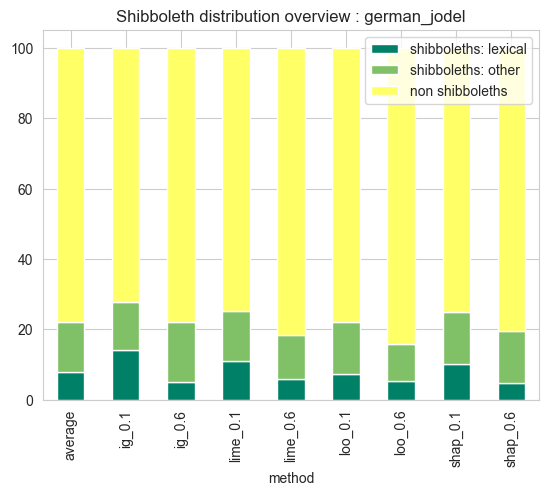

In [366]:
german_jodel_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : german_jodel").figure.savefig('german_jodel_shib_overview.pdf', bbox_inches='tight')

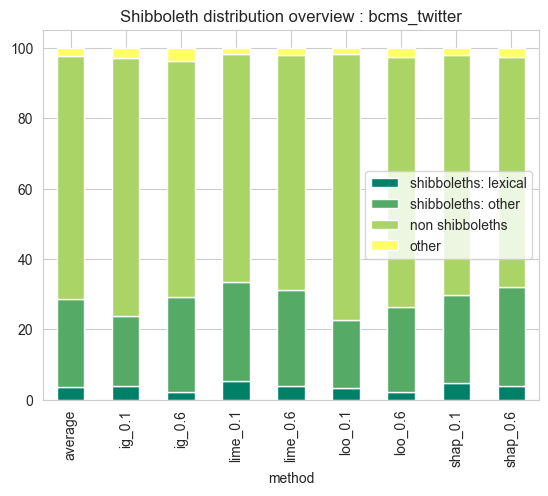

In [367]:
bcms_twitter_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : bcms_twitter").figure.savefig('bcms_twitter_shib_overview.pdf', bbox_inches='tight')

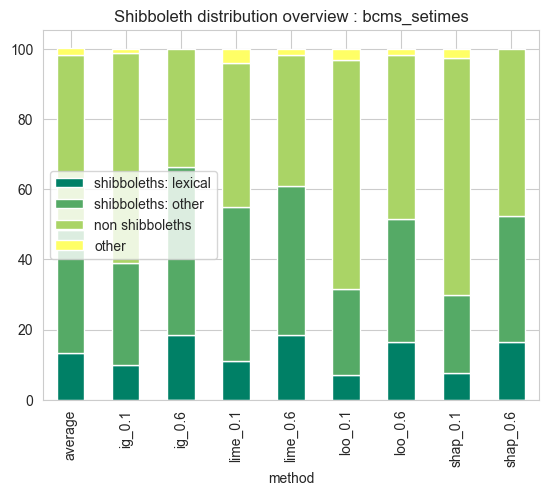

In [368]:
bcms_setimes_overview.plot(kind='bar', colormap="summer", stacked=True, title="Shibboleth distribution overview : bcms_setimes").figure.savefig('bcms_setimes_shib_overview.pdf', bbox_inches='tight')

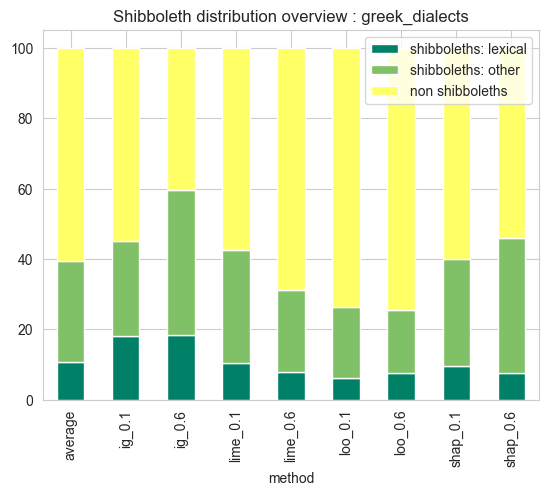

In [369]:
greek_dialects_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : greek_dialects").figure.savefig('greek_dialects_shib_overview.pdf', bbox_inches='tight')

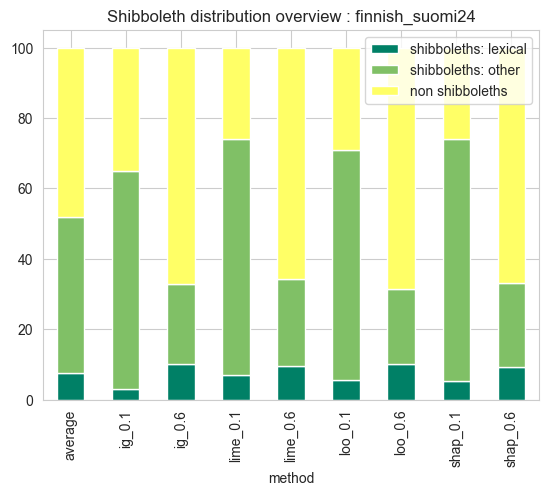

In [370]:
finnish_suomi24_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : finnish_suomi24").figure.savefig('finnish_suomi24_shib_overview.pdf', bbox_inches='tight')

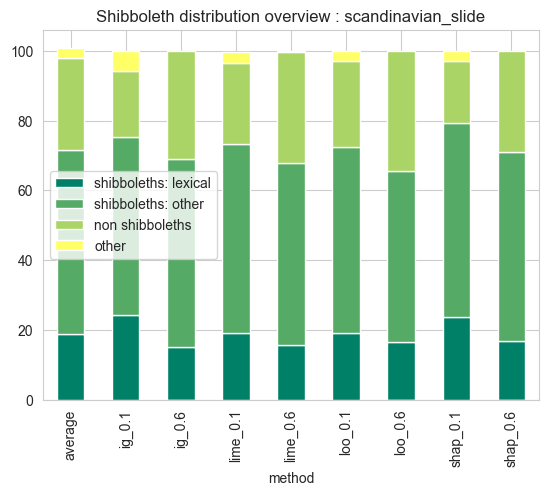

In [371]:
scandinavian_slide_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : scandinavian_slide").figure.savefig('scandinavian_slide_shib_overview.pdf', bbox_inches='tight')

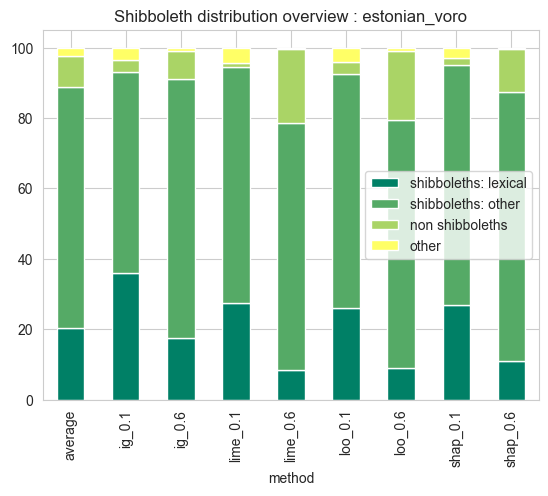

In [372]:
estonian_voro_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : estonian_voro").figure.savefig('estonian_voro_shib_overview.pdf', bbox_inches='tight')

## Generating csv tables with main results

In [373]:
bcms_setimes_overview.to_csv('bcms_setimes_overview.csv')
bcms_twitter_overview.to_csv('bcms_twitter_overview.csv')
finnish_suomi24_overview.to_csv('finnish_suomi24_overview.csv')
german_jodel_overview.to_csv('german_jodel_overview.csv')
greek_dialects_overview.to_csv('greek_dialects_overview.csv')
scandinavian_slide_overview.to_csv('scandinavian_slide_overview.csv')
estonian_voro_overview.to_csv('estonian_voro_overview.csv')

# Analysis by method 

In [374]:
bcms_setimes_overview.loc[:, 'dataset'] = 'bcms_setimes'
bcms_setimes_overview

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/114774054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bcms_setimes_overview.loc[:, 'dataset'] = 'bcms_setimes'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,13.2,35.2,49.9,2.2,bcms_setimes
ig_0.1,10.0,29.0,60.0,1.0,bcms_setimes
ig_0.6,18.5,48.0,33.5,NaN,bcms_setimes
lime_0.1,11.0,44.0,41.0,4.0,bcms_setimes
lime_0.6,18.5,42.5,37.5,1.5,bcms_setimes
loo_0.1,7.0,24.5,65.5,3.0,bcms_setimes
loo_0.6,16.5,35.0,47.0,1.5,bcms_setimes
shap_0.1,7.5,22.5,67.5,2.5,bcms_setimes
shap_0.6,16.5,36.0,47.5,NaN,bcms_setimes


In [375]:
bcms_twitter_overview.loc[:, 'dataset'] = 'bcms_twitter'
bcms_twitter_overview

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/3093288178.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bcms_twitter_overview.loc[:, 'dataset'] = 'bcms_twitter'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,3.7,24.9,69.0,2.4,bcms_twitter
ig_0.1,4.0,19.8,73.2,3.0,bcms_twitter
ig_0.6,2.2,27.0,67.2,3.5,bcms_twitter
lime_0.1,5.2,28.2,64.8,1.8,bcms_twitter
lime_0.6,3.8,27.3,67.0,2.0,bcms_twitter
loo_0.1,3.2,19.5,75.5,1.8,bcms_twitter
loo_0.6,2.2,24.2,71.0,2.5,bcms_twitter
shap_0.1,4.8,25.0,68.2,2.0,bcms_twitter
shap_0.6,4.0,28.0,65.5,2.5,bcms_twitter


In [376]:
finnish_suomi24_overview.loc[:, 'dataset'] = 'finnish_suomi24'
finnish_suomi24_overview

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/3544459959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  finnish_suomi24_overview.loc[:, 'dataset'] = 'finnish_suomi24'


,shibboleths: lexical,shibboleths: other,non shibboleths,dataset
method,,,,
average,7.5,44.4,48.0,finnish_suomi24
ig_0.1,3.0,62.0,35.0,finnish_suomi24
ig_0.6,10.2,22.6,67.2,finnish_suomi24
lime_0.1,7.0,67.0,26.0,finnish_suomi24
lime_0.6,9.5,24.9,65.6,finnish_suomi24
loo_0.1,5.7,65.3,29.0,finnish_suomi24
loo_0.6,10.1,21.3,68.6,finnish_suomi24
shap_0.1,5.3,68.7,26.0,finnish_suomi24
shap_0.6,9.2,23.8,67.0,finnish_suomi24


In [377]:
german_jodel_overview.loc[:, 'dataset'] = 'german_jodel'
german_jodel_overview

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/3181395630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  german_jodel_overview.loc[:, 'dataset'] = 'german_jodel'


,shibboleths: lexical,shibboleths: other,non shibboleths,dataset
method,,,,
average,7.9,14.1,78.0,german_jodel
ig_0.1,14.2,13.5,72.2,german_jodel
ig_0.6,5.0,17.2,77.8,german_jodel
lime_0.1,11.0,14.2,74.8,german_jodel
lime_0.6,5.8,12.5,81.8,german_jodel
loo_0.1,7.2,15.0,77.8,german_jodel
loo_0.6,5.2,10.5,84.2,german_jodel
shap_0.1,10.0,14.8,75.2,german_jodel
shap_0.6,4.8,14.8,80.5,german_jodel


In [378]:
greek_dialects_overview.loc[:, 'dataset'] = 'greek_dialects'
greek_dialects_overview

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/3640696615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  greek_dialects_overview.loc[:, 'dataset'] = 'greek_dialects'


,shibboleths: lexical,shibboleths: other,non shibboleths,dataset
method,,,,
average,10.7,28.8,60.5,greek_dialects
ig_0.1,18.0,27.0,55.0,greek_dialects
ig_0.6,18.5,41.0,40.5,greek_dialects
lime_0.1,10.5,32.0,57.5,greek_dialects
lime_0.6,7.8,23.5,68.8,greek_dialects
loo_0.1,6.2,20.0,73.8,greek_dialects
loo_0.6,7.5,18.0,74.5,greek_dialects
shap_0.1,9.5,30.5,60.0,greek_dialects
shap_0.6,7.5,38.5,54.0,greek_dialects


In [379]:
scandinavian_slide_overview.loc[:, 'dataset'] = 'scandinavian_slide'
scandinavian_slide_overview

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/265752419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scandinavian_slide_overview.loc[:, 'dataset'] = 'scandinavian_slide'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,18.8,52.9,26.4,2.9,scandinavian_slide
ig_0.1,24.2,51.2,19.0,5.5,scandinavian_slide
ig_0.6,15.2,53.8,31.0,NaN,scandinavian_slide
lime_0.1,19.2,54.2,23.2,3.2,scandinavian_slide
lime_0.6,15.8,52.2,31.8,0.2,scandinavian_slide
loo_0.1,19.2,53.2,24.8,2.8,scandinavian_slide
loo_0.6,16.5,49.0,34.5,NaN,scandinavian_slide
shap_0.1,23.8,55.5,17.8,3.0,scandinavian_slide
shap_0.6,16.8,54.2,29.0,NaN,scandinavian_slide


In [380]:
estonian_voro_overview.loc[:, 'dataset'] = 'estonian_voro'
estonian_voro_overview

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/3872683280.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estonian_voro_overview.loc[:, 'dataset'] = 'estonian_voro'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,20.3,68.6,8.8,2.2,estonian_voro
ig_0.1,36.0,57.0,3.5,3.5,estonian_voro
ig_0.6,17.5,73.5,8.0,1.0,estonian_voro
lime_0.1,27.5,67.0,1.0,4.5,estonian_voro
lime_0.6,8.5,70.0,21.0,0.5,estonian_voro
loo_0.1,26.0,66.5,3.5,4.0,estonian_voro
loo_0.6,9.0,70.5,19.5,1.0,estonian_voro
shap_0.1,27.0,68.0,2.0,3.0,estonian_voro
shap_0.6,11.0,76.5,12.0,0.5,estonian_voro


In [381]:
all_overview = pd.concat([bcms_twitter_overview, bcms_setimes_overview, finnish_suomi24_overview, \
                         german_jodel_overview, greek_dialects_overview, scandinavian_slide_overview, estonian_voro_overview], axis=0).reset_index(names=['method'])
#all_overview['method'] = all_overview['method'].str.split("_", expand=True)[0].str.upper() + ", p=" + all_overview['method'].str.split("_", expand=True)[1]
all_overview['method'] = all_overview['method'].map({
	"ig_0.1": "IG, $p=0.1$",
	"ig_0.6": "IG, $p=0.6$",
	"lime_0.1": "LIME, $p=0.1$",
	"lime_0.6": "LIME, $p=0.6$",
	"loo_0.1": "LOO, $p=0.1$",
	"loo_0.6": "LOO, $p=0.6$",
	"shap_0.1": "SHAP, $p=0.1$",
	"shap_0.6": "SHAP, $p=0.6$",
	"average": "average"
})
all_overview["other"] = all_overview["other"].fillna(0)
all_overview

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
0,average,3.7,24.9,69.0,2.4,bcms_twitter
1,"IG, $p=0.1$",4.0,19.8,73.2,3.0,bcms_twitter
2,"IG, $p=0.6$",2.2,27.0,67.2,3.5,bcms_twitter
3,"LIME, $p=0.1$",5.2,28.2,64.8,1.8,bcms_twitter
4,"LIME, $p=0.6$",3.8,27.3,67.0,2.0,bcms_twitter
...,...,...,...,...,...,...
58,"LIME, $p=0.6$",8.5,70.0,21.0,0.5,estonian_voro
59,"LOO, $p=0.1$",26.0,66.5,3.5,4.0,estonian_voro
60,"LOO, $p=0.6$",9.0,70.5,19.5,1.0,estonian_voro
61,"SHAP, $p=0.1$",27.0,68.0,2.0,3.0,estonian_voro


In [382]:
all_overview[all_overview['method'] == 'IG, $p=0.1$'].set_index('dataset')

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other
dataset,,,,,
bcms_twitter,"IG, $p=0.1$",4.0,19.8,73.2,3.0
bcms_setimes,"IG, $p=0.1$",10.0,29.0,60.0,1.0
finnish_suomi24,"IG, $p=0.1$",3.0,62.0,35.0,0.0
german_jodel,"IG, $p=0.1$",14.2,13.5,72.2,0.0
greek_dialects,"IG, $p=0.1$",18.0,27.0,55.0,0.0
scandinavian_slide,"IG, $p=0.1$",24.2,51.2,19.0,5.5
estonian_voro,"IG, $p=0.1$",36.0,57.0,3.5,3.5


## Generate graphs by method

In [383]:
import matplotlib.cm as cm
import numpy as np

In [384]:
mean_lex_df = all_overview[all_overview['method'] == 'average'] #reset_index(names=['dataset'])
mean_lex_df.set_index('dataset', inplace=True)
mean_lex_df

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other
dataset,,,,,
bcms_twitter,average,3.7,24.9,69.0,2.4
bcms_setimes,average,13.2,35.2,49.9,2.2
finnish_suomi24,average,7.5,44.4,48.0,0.0
german_jodel,average,7.9,14.1,78.0,0.0
greek_dialects,average,10.7,28.8,60.5,0.0
scandinavian_slide,average,18.8,52.9,26.4,2.9
estonian_voro,average,20.3,68.6,8.8,2.2


In [385]:
mean_ev = mean_lex_df.loc['estonian_voro', 'shibboleths: lexical']
mean_twit = mean_lex_df.loc['bcms_setimes', 'shibboleths: lexical']
mean_set = mean_lex_df.loc['bcms_twitter', 'shibboleths: lexical']
mean_suomi24 = mean_lex_df.loc['finnish_suomi24', 'shibboleths: lexical']
mean_jodel = mean_lex_df.loc['german_jodel', 'shibboleths: lexical']
mean_greek = mean_lex_df.loc['greek_dialects', 'shibboleths: lexical']
mean_slide = mean_lex_df.loc['scandinavian_slide', 'shibboleths: lexical']

In [386]:
all_overview = all_overview[all_overview['method'] != 'average']
all_overview


,method,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
1,"IG, $p=0.1$",4.0,19.8,73.2,3.0,bcms_twitter
2,"IG, $p=0.6$",2.2,27.0,67.2,3.5,bcms_twitter
3,"LIME, $p=0.1$",5.2,28.2,64.8,1.8,bcms_twitter
4,"LIME, $p=0.6$",3.8,27.3,67.0,2.0,bcms_twitter
5,"LOO, $p=0.1$",3.2,19.5,75.5,1.8,bcms_twitter
6,"LOO, $p=0.6$",2.2,24.2,71.0,2.5,bcms_twitter
7,"SHAP, $p=0.1$",4.8,25.0,68.2,2.0,bcms_twitter
8,"SHAP, $p=0.6$",4.0,28.0,65.5,2.5,bcms_twitter
10,"IG, $p=0.1$",10.0,29.0,60.0,1.0,bcms_setimes
11,"IG, $p=0.6$",18.5,48.0,33.5,0.0,bcms_setimes


['Mean % of lexical shibboleths', 'shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']


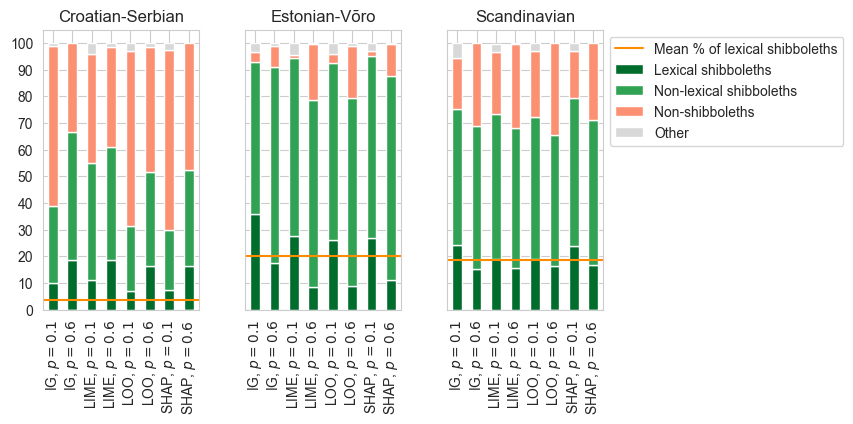

In [387]:
from matplotlib.colors import ListedColormap

# in RGB 256. Picked from https://colorbrewer2.org/
colors = [(0,109,44), (49,163,84), (252,146,114), (217, 217, 217)]
colors = [tuple(e/ 256 for e in color) for color in colors]
cmap = ListedColormap(colors, name='from_list', N=4)
sns.set_style("whitegrid")

fig, axes = plt.subplots(nrows=1, ncols=3, sharey='row', figsize=(7,3.5))
all_overview[all_overview['dataset'] == 'bcms_setimes'].set_index('method').plot(kind='bar', stacked=True, title="Croatian-Serbian",  colormap=cmap, ax=axes[0], legend=False)
all_overview[all_overview['dataset'] == 'estonian_voro'].set_index('method').plot(kind='bar', stacked=True, title="Estonian-Võro",  colormap=cmap, ax=axes[1], legend=False)
all_overview[all_overview['dataset'] == 'scandinavian_slide'].set_index('method').plot(kind='bar', stacked=True, title="Scandinavian",  colormap=cmap, ax=axes[2], legend=False)

axes[0].set_yticks(range(0, 105, 10))
axes[0].set_ylim(0, 105)

axes[0].set_xlabel(None)
axes[1].set_xlabel(None)
axes[2].set_xlabel(None)

## adding mean line
axes[2].axhline(mean_slide, color='darkorange', linestyle='-')
#axes[0].text(0, mean_slide + 0.2, f'{mean_slide:.2f}', color='darkorange', weight='bold')
axes[0].axhline(mean_set, color='darkorange', linestyle='-')
#axes[1].text(0, mean_set + 0.2, f'{mean_set:.2f}', color='darkorange')
axes[1].axhline(mean_ev, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
#axes[2].text(0, mean_ev + 0.2, f'{mean_ev:.2f}', color='darkorange')

ax=axes[1]
handles, labels = ax.get_legend_handles_labels()
print(labels)
#fig.legend(handles, labels, loc='upper center')
plt.legend(
    handles, 
    ['Mean % of lexical shibboleths', 'Lexical shibboleths', 'Non-lexical shibboleths', 'Non-shibboleths', 'Other'], 
    loc='upper left', bbox_to_anchor=(0.9, 0.9), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1,
                    wspace=0.3, hspace=0.5
                   )
fig.figure.savefig('experiment1-overview.pdf', bbox_inches='tight')


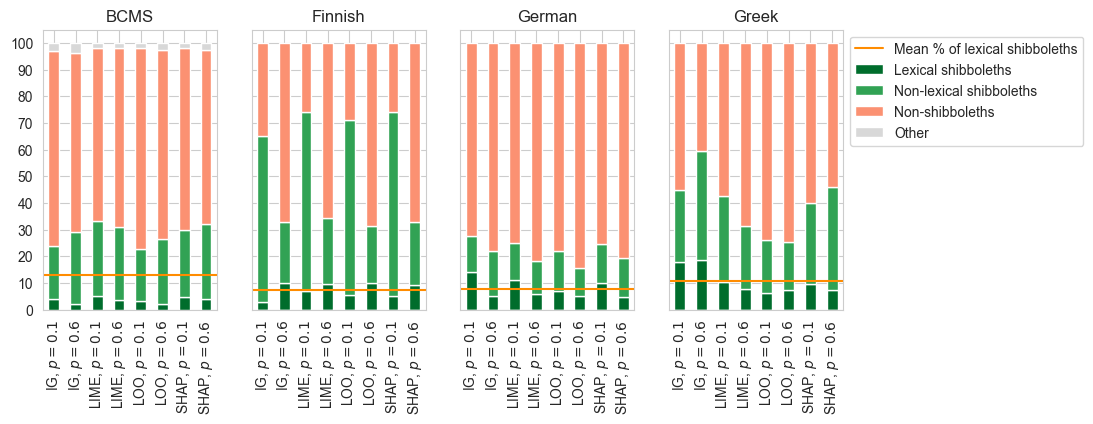

In [388]:
fig, axes = plt.subplots(nrows=1, ncols=4, sharey='row', figsize=(10,3.5))
all_overview[all_overview['dataset'] == 'bcms_twitter'].set_index('method').plot(kind='bar', stacked=True, title="BCMS",  colormap=cmap, ax=axes[0], legend=False)
all_overview[all_overview['dataset'] == 'finnish_suomi24'].set_index('method').plot(kind='bar', stacked=True, title="Finnish",  colormap=cmap, ax=axes[1], legend=False)
all_overview[all_overview['dataset'] == 'german_jodel'].set_index('method').plot(kind='bar', stacked=True, title="German",  colormap=cmap, ax=axes[2], legend=False)
all_overview[all_overview['dataset'] == 'greek_dialects'].set_index('method').plot(kind='bar', stacked=True, title="Greek",  colormap=cmap, ax=axes[3], legend=False)                                                                                 
axes[0].set_yticks(range(0, 105, 10))
axes[0].set_ylim(0, 105)

axes[0].set_xlabel(None)
axes[1].set_xlabel(None)
axes[2].set_xlabel(None)
axes[3].set_xlabel(None)

axes[0].axhline(mean_twit, color='darkorange', linestyle='-')
axes[1].axhline(mean_suomi24, color='darkorange', linestyle='-')
axes[2].axhline(mean_jodel, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
axes[3].axhline(mean_greek, color='darkorange', linestyle='-')

ax=axes[2]
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
plt.legend(
    handles, 
    ['Mean % of lexical shibboleths', 'Lexical shibboleths', 'Non-lexical shibboleths', 'Non-shibboleths', 'Other'], 
    loc='upper left', bbox_to_anchor=(0.9, 0.9), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.2, hspace=0.5
                   )
fig.figure.savefig('experiment2-overview.pdf', bbox_inches='tight')

### RESULTS PER DATASET, PER CLASS

## BCMS SETIMES

In [389]:
bcms_setimes_df2 = bcms_setimes_df.set_index('file', drop=True)
bcms_setimes_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note
file,,,,,,,,,
list6,natjecateljskom,hr,0.241601,0.70,True,yes,lex,NaN,NaN
list6,liječniku,hr,0.232991,0.67,True,yes,lex,NaN,jek
list6,slijedili,hr,0.228810,0.69,True,no,phon,NaN,jek
list6,natjecalo,hr,0.221181,0.66,True,yes,lex,NaN,NaN
list6,strijelac,hr,0.211338,0.87,True,no,phon,NaN,jek
...,...,...,...,...,...,...,...,...,...
list8,predsedavati,sr,0.362739,0.65,False,yes,phon,NaN,NaN
list8,saopštavajući,sr,0.362684,0.92,False,yes,phon,NaN,NaN
list8,evroatlantske,sr,0.362167,1.00,False,yes,phon,nonminimal,NaN


In [390]:
bcms_setimes_methods_df

,method
average,average
list1,loo_0.6
list2,loo_0.1
list3,shap_0.6
list4,shap_0.1
list5,ig_0.1
list6,lime_0.6
list7,lime_0.1
list8,ig_0.6


In [391]:
bcms_setimes_df2 = bcms_setimes_df2.join(bcms_setimes_methods_df, how='left', on=None)

In [392]:
bcms_setimes_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,method
file,,,,,,,,,,
list6,natjecateljskom,hr,0.241601,0.70,True,yes,lex,NaN,NaN,lime_0.6
list6,liječniku,hr,0.232991,0.67,True,yes,lex,NaN,jek,lime_0.6
list6,slijedili,hr,0.228810,0.69,True,no,phon,NaN,jek,lime_0.6
list6,natjecalo,hr,0.221181,0.66,True,yes,lex,NaN,NaN,lime_0.6
list6,strijelac,hr,0.211338,0.87,True,no,phon,NaN,jek,lime_0.6
...,...,...,...,...,...,...,...,...,...,...
list8,predsedavati,sr,0.362739,0.65,False,yes,phon,NaN,NaN,ig_0.6
list8,saopštavajući,sr,0.362684,0.92,False,yes,phon,NaN,NaN,ig_0.6
list8,evroatlantske,sr,0.362167,1.00,False,yes,phon,nonminimal,NaN,ig_0.6


In [393]:
methods = ['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6']
methods_pretty = [
    'IG, $p=0.1$', 'IG, $p=0.6$', 
    'LIME, $p=0.1$', 'LIME, $p=0.6$', 
    'LOO, $p=0.1$', 'LOO, $p=0.6$', 
    'SHAP, $p=0.1$', 'SHAP, $p=0.6$', ]
classes = ['hr', 'sr']

counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = bcms_setimes_df2[(bcms_setimes_df2['method'] == m) & (bcms_setimes_df2['label'] == c)]
        lex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['feature'] == 'lex')])
        nonlex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['feature'] != 'lex')])
        nonshib = len(work_df[(work_df['shibboleth'] == 'no')])
        other = len(work_df[(work_df['shibboleth'] != 'yes') & (work_df['shibboleth'] != 'no')])
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])


In [394]:
counts_df = pd.DataFrame.from_dict(counts, orient='index').stack().to_frame()
counts_df[['Lexical shibboleths', 'Non-lexical shibboleths', 'Non-shibboleths', 'Other', 'sum']] = counts_df.loc[:, 0].to_list()
counts_df = counts_df.drop(columns=[counts_df.columns[0]]).drop(columns=['sum'])
counts_df.to_csv('cs_setimes.csv')
counts_df

Lexical shibboleths  Non-lexical shibboleths  Non-shibboleths  \
ig_0.1   hr                   14                       14               72   
         sr                    6                       44               48   
ig_0.6   hr                   23                       15               62   
         sr                   14                       81                5   
lime_0.1 hr                    7                       22               70   
         sr                   15                       66               12   
lime_0.6 hr                   22                       17               60   
         sr                   15                       68               15   
loo_0.1  hr                    9                       17               71   
         sr                    5                       32               60   
loo_0.6  hr                   21                       13               66   
         sr                   12                       57               28   
shap_0.1 hr                   10                       18               71   
         sr                    5                       27               64   
shap_0.6 hr                   22                       18               60   
         sr                   11                       54               35   

             Other  
ig_0.1   hr      0  
         sr      2  
ig_0.6   hr      0  
         sr      0  
lime_0.1 hr      1  
         sr      7  
lime_0.6 hr      1  
         sr      2  
loo_0.1  hr      3  
         sr      3  
loo_0.6  hr      0  
         sr      3  
shap_0.1 hr      1  
         sr      4  
shap_0.6 hr      0  
         sr      0

In [395]:
def make_graphs_per_class(counts_dict, ds, nrows=2, show_legend=True):
    
    counts = counts_dict
    outfile = ds + '_perclass.pdf'

    counts_df = pd.DataFrame.from_dict(counts, orient='index').stack().to_frame()
    counts_df[['Lexical shibboleths', 'Non-lexical shibboleths', 'Non-shibboleths', 'Other', 'sum']] = counts_df.loc[:, 0].to_list()
    counts_df = counts_df.drop(columns=[counts_df.columns[0]]).drop(columns=['sum'])
    counts_df

    if len(counts) == 8:
        if nrows > 1:
            fig, axes = plt.subplots(nrows=nrows, ncols=4, sharey='row', figsize=(10,8))
        
            idx = -1
            for i in range(0,2):
                for j in range(0,4):
                    idx += 1  
                    m = methods[idx]
                    counts_df.loc[m].plot(kind='bar', stacked=True, title=methods_pretty[idx], colormap=cmap, ax=axes[i,j], legend=False)
                    mean = counts_df.loc[m]['Lexical shibboleths'].mean()
                # if i == 1 and j == 3:
                    axes[i,j].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
            
            axes[0, 0].set_yticks(range(0, 105, 10))
            axes[0, 0].set_ylim(0, 105)    
            axes[1, 0].set_yticks(range(0, 105, 10))
            axes[1, 0].set_ylim(0, 105)
            ax=axes[-1,-1]
        
        else:
            fig, axes = plt.subplots(nrows=1, ncols=8, sharey='row', figsize=(12,4))

            for i, m in enumerate(methods):
                counts_df.loc[m].plot(kind='bar', stacked=True, title=methods_pretty[i], colormap=cmap, ax=axes[i], width=0.5, legend=False)
                mean = counts_df.loc[m]['Lexical shibboleths'].mean()
                axes[i].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')

            axes[0].set_yticks(range(0, 105, 10))
            axes[0].set_ylim(0, 105)
            ax = axes[-1]
        
    else:
        fig, ax = plt.subplots(nrows=1, ncols=1, sharey='row', figsize=(2.5,4))
        m = next(iter(counts.keys()))
        idx = methods.tolist().index(m)
        counts_df.loc[m].plot(kind='bar', stacked=True, title=methods_pretty[idx], colormap=cmap, ax=ax, legend=False)
        mean = counts_df.loc[m]['Lexical shibboleths'].mean()
        ax.axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
        ax.set_yticks(range(0, 105, 10))
        ax.set_ylim(0, 105)
    
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        #fig.legend(handles, labels, loc='upper center')
        plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.9, 0.9), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

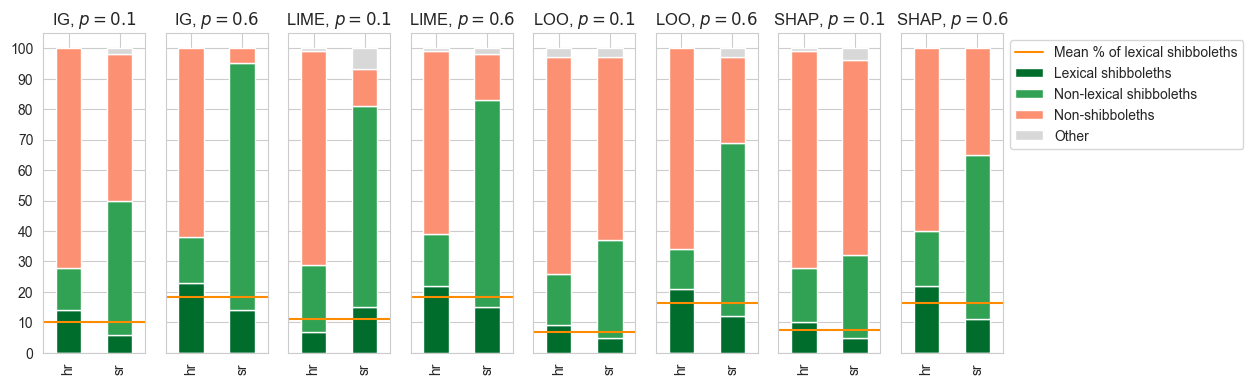

In [396]:
make_graphs_per_class(counts, 'bcms_setimes', nrows=1, show_legend=True)

## BCMS TWITTER

In [397]:
bcms_twitter_df2 = bcms_twitter_df.set_index('file', drop=True)
bcms_twitter_df2 = bcms_twitter_df2.join(bcms_twitter_methods_df, how='left' or 'inner', on=None)

In [398]:
bcms_twitter_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,method
file,,,,,,,,,,
list6,😎🌞<unk>☕️🍉,bs,1.525842,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,☕️😎,bs,1.430635,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,unk>😏,bs,1.371145,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,🙈<unk>🙊,bs,1.352293,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,👍😏,bs,1.306748,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
...,...,...,...,...,...,...,...,...,...,...
list8,neizvesno,sr,0.611152,0.114583,NaN,yes,phon,NaN,NaN,lime_0.1
list8,osetiti,sr,0.610422,0.187500,NaN,yes,phon,NaN,NaN,lime_0.1
list8,pobedama,sr,0.608175,0.104167,NaN,yes,phon,NaN,NaN,lime_0.1


In [399]:
classes = bcms_twitter_df2['label'].sort_values().unique()
classes

array(['bs', 'hr', 'me', 'sr'], dtype=object)

In [400]:
methods = bcms_twitter_df2['method'].sort_values().unique()

In [401]:
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [402]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = bcms_twitter_df2[(bcms_twitter_df2['method'] == m) & (bcms_twitter_df2['label'] == c)]
        lex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['feature'] == 'lex')])
        nonlex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['feature'] != 'lex')])
        nonshib = len(work_df[(work_df['shibboleth'] == 'no')])
        other = len(work_df[(work_df['shibboleth'] != 'yes') & (work_df['shibboleth'] != 'no')])
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])
counts

{'ig_0.1': {'bs': [14, 0, 82, 4, 100],
  'hr': [1, 3, 90, 6, 100],
  'me': [1, 7, 91, 1, 100],
  'sr': [0, 69, 30, 1, 100]},
 'ig_0.6': {'bs': [4, 0, 89, 7, 100],
  'hr': [5, 5, 85, 5, 100],
  'me': [0, 10, 89, 1, 100],
  'sr': [0, 93, 6, 1, 100]},
 'lime_0.1': {'bs': [14, 0, 84, 2, 100],
  'hr': [5, 3, 91, 1, 100],
  'me': [0, 22, 76, 2, 100],
  'sr': [2, 88, 8, 2, 100]},
 'lime_0.6': {'bs': [6, 0, 92, 2, 100],
  'hr': [8, 7, 81, 4, 100],
  'me': [0, 13, 86, 1, 100],
  'sr': [1, 89, 9, 1, 100]},
 'loo_0.1': {'bs': [10, 0, 90, 0, 100],
  'hr': [2, 1, 96, 1, 100],
  'me': [1, 7, 88, 4, 100],
  'sr': [0, 70, 28, 2, 100]},
 'loo_0.6': {'bs': [3, 0, 94, 3, 100],
  'hr': [5, 8, 83, 4, 100],
  'me': [0, 12, 86, 2, 100],
  'sr': [1, 77, 21, 1, 100]},
 'shap_0.1': {'bs': [16, 0, 81, 3, 100],
  'hr': [2, 3, 92, 3, 100],
  'me': [1, 10, 87, 2, 100],
  'sr': [0, 87, 13, 0, 100]},
 'shap_0.6': {'bs': [6, 0, 87, 7, 100],
  'hr': [10, 8, 80, 2, 100],
  'me': [0, 13, 87, 0, 100],
  'sr': [0, 91, 8, 1

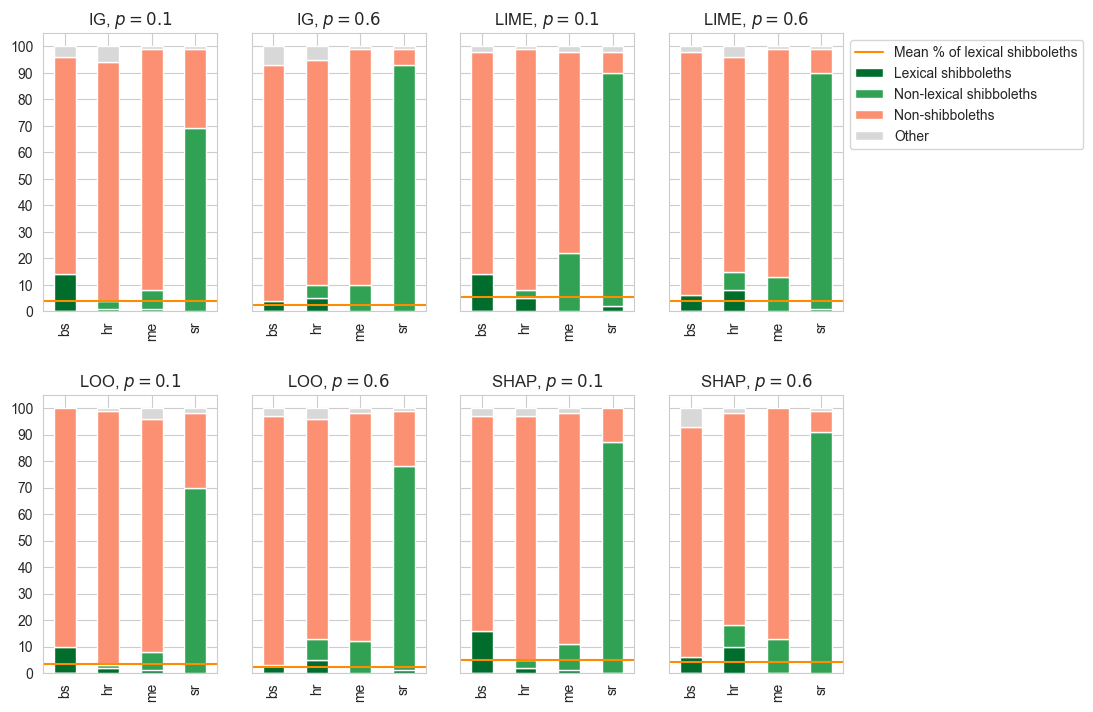

In [403]:
import pickle
with open('bcms_twitter.pkl', 'wb') as f:
    pickle.dump(counts, f)

make_graphs_per_class(counts, 'bcms_twitter')

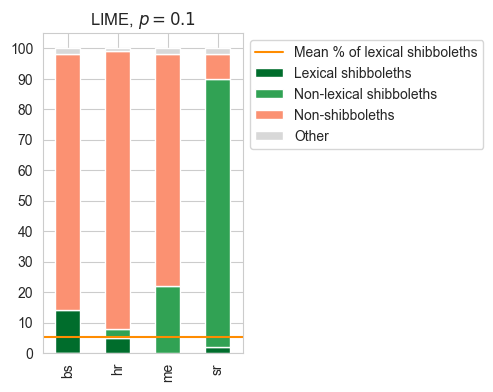

In [404]:
make_graphs_per_class({k:v for k,v in counts.items() if k == 'lime_0.1'}, 'select_bcms_twitter')

### SCANDINAVIAN_SLIDE

In [405]:
scandinavian_slide_df2 = scandinavian_slide_df.set_index('file', drop=True)
scandinavian_slide_df2 = scandinavian_slide_df2.join(scandinavian_slide_methods_df, how='left', on=None)
scandinavian_slide_df2['method'].value_counts()

method
shap_0.1    400
ig_0.1      400
lime_0.1    400
loo_0.1     400
shap_0.6    400
loo_0.6     400
ig_0.6      400
lime_0.6    400
Name: count, dtype: int64

In [406]:
classes = scandinavian_slide_df2['label'].sort_values().unique()
classes

array(['da', 'nb', 'nn', 'sv'], dtype=object)

In [407]:
methods = scandinavian_slide_df2['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [408]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = scandinavian_slide_df2[(scandinavian_slide_df2['method'] == m) & (scandinavian_slide_df2['label'] == c)]
        lex = len(work_df[work_df['LexShib'] == True])
        nonlex = len(work_df[work_df['NonLexShib'] == True])
        nonshib = len(work_df[work_df['NotShib'] == True])
        other = len(work_df[work_df['Typo_Unk'] == True])
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])
counts


{'ig_0.1': {'da': [24, 59, 12, 5, 100],
  'nb': [6, 53, 33, 8, 100],
  'nn': [20, 46, 27, 7, 100],
  'sv': [47, 47, 4, 2, 100]},
 'ig_0.6': {'da': [9, 75, 16, 0, 100],
  'nb': [7, 28, 65, 0, 100],
  'nn': [19, 51, 30, 0, 100],
  'sv': [26, 61, 13, 0, 100]},
 'lime_0.1': {'da': [25, 66, 9, 0, 100],
  'nb': [6, 34, 54, 6, 100],
  'nn': [8, 65, 23, 4, 100],
  'sv': [38, 52, 7, 3, 100]},
 'lime_0.6': {'da': [12, 71, 17, 0, 100],
  'nb': [4, 34, 62, 0, 100],
  'nn': [29, 38, 32, 1, 100],
  'sv': [18, 66, 16, 0, 100]},
 'loo_0.1': {'da': [20, 67, 12, 1, 100],
  'nb': [6, 32, 57, 5, 100],
  'nn': [11, 62, 23, 4, 100],
  'sv': [40, 52, 7, 1, 100]},
 'loo_0.6': {'da': [11, 73, 16, 0, 100],
  'nb': [3, 35, 62, 0, 100],
  'nn': [26, 28, 46, 0, 100],
  'sv': [26, 60, 14, 0, 100]},
 'shap_0.1': {'da': [26, 70, 3, 1, 100],
  'nb': [5, 43, 44, 8, 100],
  'nn': [15, 59, 23, 3, 100],
  'sv': [49, 50, 1, 0, 100]},
 'shap_0.6': {'da': [9, 80, 11, 0, 100],
  'nb': [4, 39, 57, 0, 100],
  'nn': [29, 28, 43,

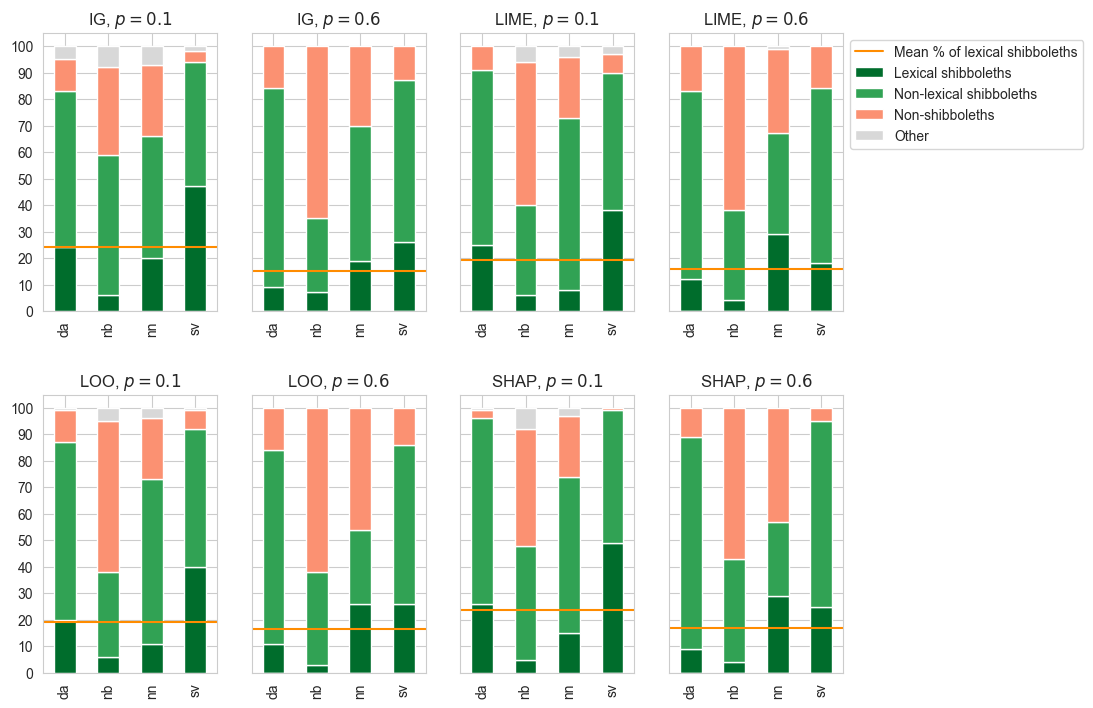

In [409]:
import pickle
with open('scandinavian_slide.pkl', 'wb') as f:
    pickle.dump(counts, f)

make_graphs_per_class(counts, 'scandinavian_slide')

### PREPARING ESTONIAN-VORO 

In [410]:
estonian_voro_df2 = estonian_voro_df.set_index('file', drop=True)
estonian_voro_df2 = estonian_voro_df2.join(estonian_voro_methods_df, how='left', on=None)
estonian_voro_df2['method'].value_counts()

method
shap_0.6    200
loo_0.1     200
lime_0.6    200
lime_0.1    200
ig_0.6      200
shap_0.1    200
loo_0.6     200
ig_0.1      200
Name: count, dtype: int64

In [411]:
classes = estonian_voro_df2['label'].sort_values().unique()
classes

array(['est', 'vro'], dtype=object)

In [412]:
methods = estonian_voro_df2['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [413]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = estonian_voro_df2[(estonian_voro_df2['method'] == m) & (estonian_voro_df2['label'] == c)]
        lex = len(work_df[work_df['lexshib'] == 1])
        nonlex = len(work_df[work_df['nonlexshib'] == 1])
        nonshib = len(work_df[work_df['noshib'] == 1])
        other = len(work_df[work_df['unk'] == 1])
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])
counts

#estonian_voro_shib_distro = estonian_voro_df[estonian_voro_df['lexshib']==1].groupby('file').size().to_frame(name="lex shib")
#estonian_voro_shib_distro['non lex shib'] = estonian_voro_df[estonian_voro_df['nonlexshib']==1].groupby('file').size()
#estonian_voro_shib_distro['non shib'] = estonian_voro_df[estonian_voro_df['noshib']==1].groupby('file').size()
#estonian_voro_shib_distro['rest'] = estonian_voro_df[estonian_voro_df['unk']==1].groupby('file').size()

{'ig_0.1': {'est': [44, 51, 3, 2, 100], 'vro': [28, 63, 4, 5, 100]},
 'ig_0.6': {'est': [20, 74, 5, 1, 100], 'vro': [15, 73, 11, 1, 100]},
 'lime_0.1': {'est': [34, 58, 2, 6, 100], 'vro': [21, 76, 0, 3, 100]},
 'lime_0.6': {'est': [12, 69, 18, 1, 100], 'vro': [5, 71, 24, 0, 100]},
 'loo_0.1': {'est': [28, 62, 7, 3, 100], 'vro': [24, 71, 0, 5, 100]},
 'loo_0.6': {'est': [14, 64, 21, 1, 100], 'vro': [4, 77, 18, 1, 100]},
 'shap_0.1': {'est': [35, 62, 2, 1, 100], 'vro': [19, 74, 2, 5, 100]},
 'shap_0.6': {'est': [18, 76, 6, 0, 100], 'vro': [4, 77, 18, 1, 100]}}

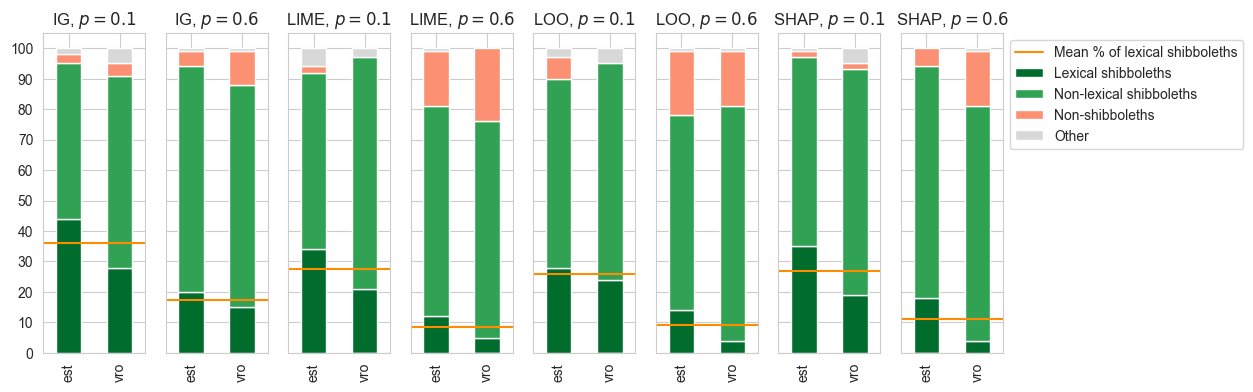

In [414]:
import pickle
with open('estonian_voro.pkl', 'wb') as f:
    pickle.dump(counts, f)

make_graphs_per_class(counts, 'estonian_voro', nrows=1, show_legend=True)

### PREPARING JODEL DATA

In [415]:
german_jodel_df2 = german_jodel_df.set_index('file', drop=True)
german_jodel_df2 = german_jodel_df2.join(german_jodel_methods_df, how='left', on=None)
german_jodel_df2['label'] = german_jodel_df2['label'].str.lower()
german_jodel_df2['method'].value_counts()

method
shap_0.1    400
loo_0.1     400
shap_0.6    400
lime_0.6    400
ig_0.1      400
lime_0.1    400
ig_0.6      400
loo_0.6     400
Name: count, dtype: int64

In [416]:
classes = german_jodel_df2['label'].sort_values().unique()
classes

array(['at', 'ch', 'de_n', 'de_s'], dtype=object)

In [417]:
methods = german_jodel_df2['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [418]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = german_jodel_df2[(german_jodel_df2['method'] == m) & (german_jodel_df2['label'] == c)]
        lex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['code'] == 'lex')])
        nonlex = len(work_df[(work_df['shibboleth'] == 'yes') & (work_df['code'] != 'lex')])
        nonshib = len(work_df[work_df['shibboleth'] == 'no'])
        other = 0
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])
counts

#german_jodel_shib_distro = german_jodel_df[(german_jodel_df['shibboleth'] == 'yes') & (german_jodel_df['code'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
#german_jodel_shib_distro['nonlex shib'] = german_jodel_df[(german_jodel_df['shibboleth'] == 'yes') & (german_jodel_df['code'] != 'lex')].groupby('file').size()
#german_jodel_shib_distro['non shib'] = german_jodel_df[german_jodel_df['shibboleth'] == 'no'].groupby('file').size()

{'ig_0.1': {'at': [14, 11, 75, 0, 100],
  'ch': [18, 42, 40, 0, 100],
  'de_n': [2, 1, 97, 0, 100],
  'de_s': [23, 0, 77, 0, 100]},
 'ig_0.6': {'at': [8, 5, 87, 0, 100],
  'ch': [10, 64, 26, 0, 100],
  'de_n': [0, 0, 100, 0, 100],
  'de_s': [2, 0, 98, 0, 100]},
 'lime_0.1': {'at': [16, 17, 67, 0, 100],
  'ch': [13, 40, 47, 0, 100],
  'de_n': [2, 0, 98, 0, 100],
  'de_s': [13, 0, 87, 0, 100]},
 'lime_0.6': {'at': [5, 5, 90, 0, 100],
  'ch': [16, 45, 39, 0, 100],
  'de_n': [0, 0, 100, 0, 100],
  'de_s': [2, 0, 98, 0, 100]},
 'loo_0.1': {'at': [11, 17, 72, 0, 100],
  'ch': [8, 43, 49, 0, 100],
  'de_n': [0, 0, 100, 0, 100],
  'de_s': [10, 0, 90, 0, 100]},
 'loo_0.6': {'at': [6, 6, 88, 0, 100],
  'ch': [13, 36, 51, 0, 100],
  'de_n': [0, 0, 100, 0, 100],
  'de_s': [2, 0, 98, 0, 100]},
 'shap_0.1': {'at': [15, 14, 71, 0, 100],
  'ch': [16, 45, 39, 0, 100],
  'de_n': [0, 0, 100, 0, 100],
  'de_s': [9, 0, 91, 0, 100]},
 'shap_0.6': {'at': [4, 8, 88, 0, 100],
  'ch': [14, 51, 35, 0, 100],
  'd

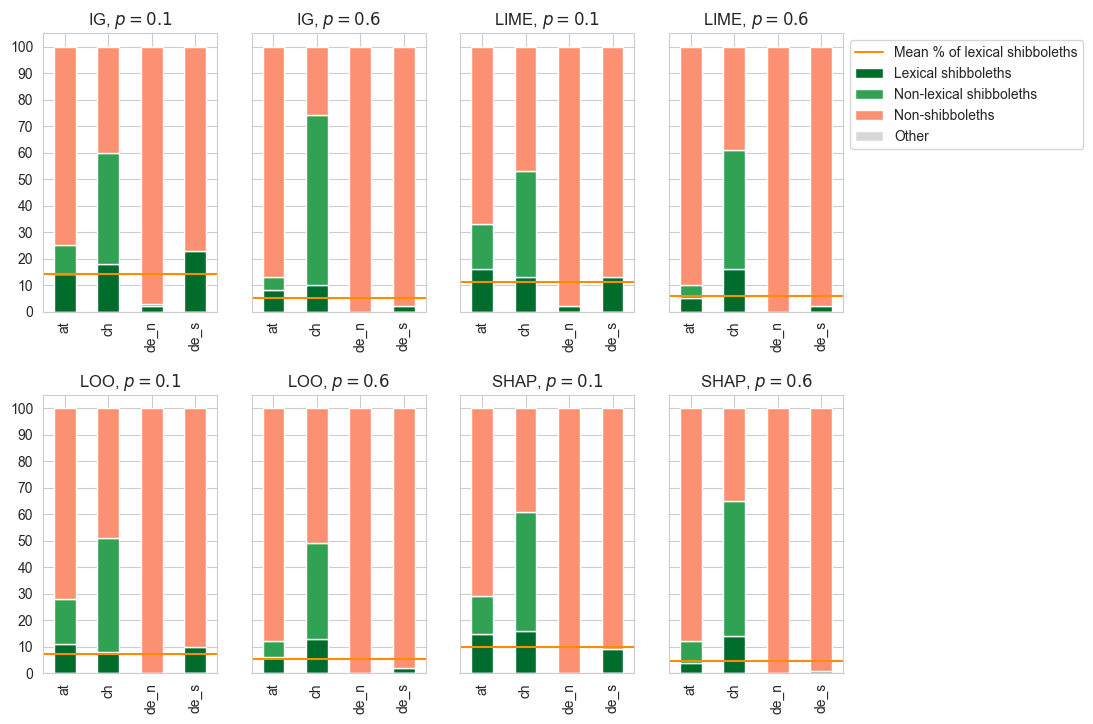

In [419]:
import pickle
with open('german_jodel.pkl', 'wb') as f:
    pickle.dump(counts, f)

make_graphs_per_class(counts, 'german_jodel')

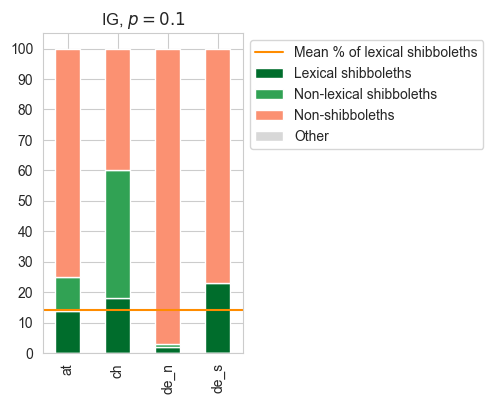

In [420]:
make_graphs_per_class({k:v for k,v in counts.items() if k == 'ig_0.1'}, 'select_german_jodel')

### PREPARING GREEK DATA

In [421]:
greek_dialects_df2 = greek_dialects_df.set_index('file', drop=True)
greek_dialects_df2 = greek_dialects_df2.join(greek_dialects_methods_df, how='left', on=None)
greek_dialects_df2['label'] = greek_dialects_df2['label'].str.lower()
greek_dialects_df2['method'].value_counts()

method
ig_0.1      400
lime_0.6    400
shap_0.6    400
loo_0.6     400
ig_0.6      400
loo_0.1     400
shap_0.1    400
lime_0.1    400
Name: count, dtype: int64

In [422]:
classes = greek_dialects_df2['label'].sort_values().unique()
classes

array(['cre', 'cyp', 'nor', 'pon'], dtype=object)

In [423]:
methods = greek_dialects_df2['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [424]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = greek_dialects_df2[(greek_dialects_df2['method'] == m) & (greek_dialects_df2['label'] == c)]
        lex = len(work_df[work_df['feature'] == 'Lex'])
        nonlex = len(work_df[(work_df['feature'] != 'NE') & (work_df['feature'] != 'Unmarked') & (work_df['feature'] != 'Lex')])
        nonshib = len(work_df[(work_df['feature'] == 'NE') | (work_df['feature'] == 'Unmarked')])
        other = 0
        sum = lex + nonlex + nonshib + other
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum])
counts

#greek_dialects_shib_distro = greek_dialects_df[greek_dialects_df['feature'] == 'Lex'].groupby('file').size().to_frame(name='lex shib')
#greek_dialects_shib_distro['nonlex shib'] = greek_dialects_df[(greek_dialects_df['feature'] != 'NE') & (greek_dialects_df['feature'] != 'Unmarked') & (greek_dialects_df['feature'] != 'Lex')].groupby('file').size()
#greek_dialects_shib_distro['non shib'] = greek_dialects_df[(greek_dialects_df['feature'] == 'NE') | (greek_dialects_df['feature'] == 'Unmarked')].groupby('file').size()

{'ig_0.1': {'cre': [25, 23, 52, 0, 100],
  'cyp': [6, 7, 87, 0, 100],
  'nor': [10, 60, 30, 0, 100],
  'pon': [31, 18, 51, 0, 100]},
 'ig_0.6': {'cre': [25, 38, 37, 0, 100],
  'cyp': [6, 31, 63, 0, 100],
  'nor': [10, 56, 34, 0, 100],
  'pon': [33, 39, 28, 0, 100]},
 'lime_0.1': {'cre': [19, 48, 33, 0, 100],
  'cyp': [12, 22, 66, 0, 100],
  'nor': [7, 46, 47, 0, 100],
  'pon': [4, 12, 84, 0, 100]},
 'lime_0.6': {'cre': [11, 27, 62, 0, 100],
  'cyp': [1, 4, 95, 0, 100],
  'nor': [6, 46, 48, 0, 100],
  'pon': [13, 17, 70, 0, 100]},
 'loo_0.1': {'cre': [7, 21, 72, 0, 100],
  'cyp': [8, 13, 79, 0, 100],
  'nor': [5, 35, 60, 0, 100],
  'pon': [5, 11, 84, 0, 100]},
 'loo_0.6': {'cre': [15, 14, 71, 0, 100],
  'cyp': [2, 5, 93, 0, 100],
  'nor': [7, 32, 61, 0, 100],
  'pon': [6, 21, 73, 0, 100]},
 'shap_0.1': {'cre': [8, 25, 67, 0, 100],
  'cyp': [14, 15, 71, 0, 100],
  'nor': [9, 68, 23, 0, 100],
  'pon': [7, 14, 79, 0, 100]},
 'shap_0.6': {'cre': [9, 38, 53, 0, 100],
  'cyp': [6, 44, 50, 0, 

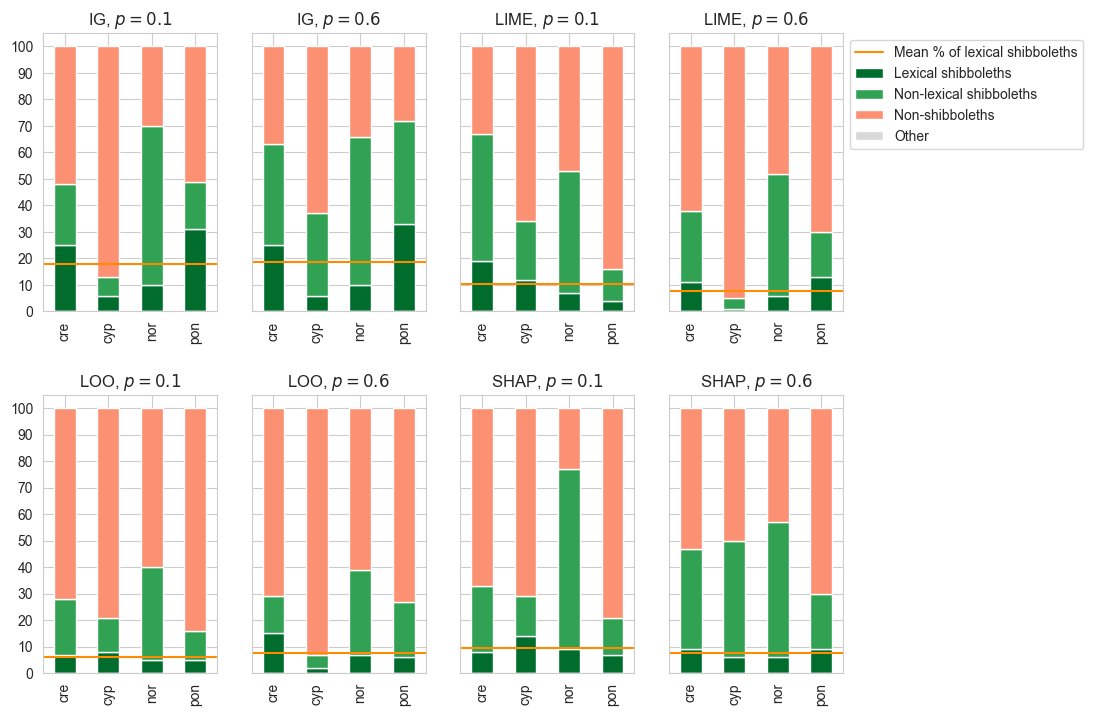

In [425]:
import pickle
with open('greek_dialects.pkl', 'wb') as f:
    pickle.dump(counts, f)

make_graphs_per_class(counts, 'greek_dialects')

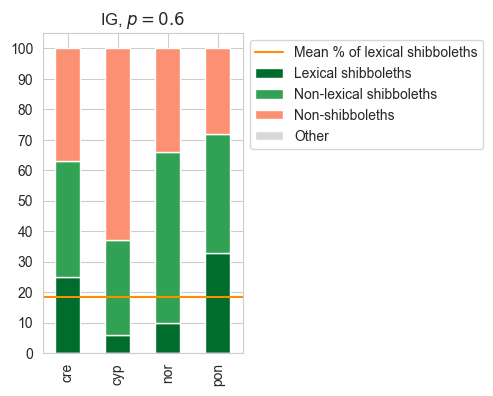

In [426]:
make_graphs_per_class({k:v for k,v in counts.items() if k == 'ig_0.6'}, 'select_greek_dialect')

### PREPARING FINNISH DATA

In [427]:
finnish_suomi24_df2 = finnish_suomi24_df.set_index('file', drop=True)
finnish_suomi24_df2 = finnish_suomi24_df2.join(finnish_suomi24_methods_df, how='left', on=None)
finnish_suomi24_df2['method'].value_counts()

method
shap_0.1    300
loo_0.1     300
lime_0.1    300
ig_0.1      300
lime_0.6    221
loo_0.6     207
shap_0.6    206
ig_0.6      186
Name: count, dtype: int64

In [428]:
sums = finnish_suomi24_df2.groupby(['method', 'label']).size()
sums

method    label
ig_0.1    east     100
          north    100
          west     100
ig_0.6    east      63
          north     64
          west      59
lime_0.1  east     100
          north    100
          west     100
lime_0.6  east      72
          north     77
          west      72
loo_0.1   east     100
          north    100
          west     100
loo_0.6   east      71
          north     68
          west      68
shap_0.1  east     100
          north    100
          west     100
shap_0.6  east      67
          north     71
          west      68
dtype: int64

In [429]:
methods = finnish_suomi24_df2['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [430]:
classes = finnish_suomi24_df2['label'].sort_values().unique()
classes

array(['east', 'north', 'west'], dtype=object)

In [431]:
counts = {}

for m in methods:
    counts[m] = {}
    for c in classes:
        counts[m][c] = []
        work_df = finnish_suomi24_df2[(finnish_suomi24_df2['method'] == m) & (finnish_suomi24_df2['label'] == c)]
        lex = len(work_df[work_df['lex_other_not'] == 'lex'])
        nonlex = len(work_df[work_df['lex_other_not'] == 'other'])
        nonshib = len(work_df[work_df['lex_other_not'] == 'not'])
        other = 0
       # sum = lex + nonlex + nonshib + other
        lex = round(lex / sums[m][c] * 100, 1)
        nonlex = round(nonlex / sums[m][c] * 100, 1)
        nonshib = round(nonshib / sums[m][c] * 100, 1)
        sum2 = lex + nonlex + nonshib
        
        counts[m][c].extend([lex, nonlex, nonshib, other, sum2])
counts

# finnish_suomi24_shib_distro = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] == 'lex'].groupby('file').size().to_frame(name='lex shib')
# finnish_suomi24_shib_distro['nonlex shib'] = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] == 'other'].groupby('file').size()
# finnish_suomi24_shib_distro['non shib'] = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] ==  'not'].groupby('file').size()

{'ig_0.1': {'east': [np.float64(0.0),
   np.float64(91.0),
   np.float64(9.0),
   0,
   np.float64(100.0)],
  'north': [np.float64(1.0),
   np.float64(53.0),
   np.float64(46.0),
   0,
   np.float64(100.0)],
  'west': [np.float64(8.0),
   np.float64(42.0),
   np.float64(50.0),
   0,
   np.float64(100.0)]},
 'ig_0.6': {'east': [np.float64(9.5),
   np.float64(30.2),
   np.float64(60.3),
   0,
   np.float64(100.0)],
  'north': [np.float64(7.8),
   np.float64(25.0),
   np.float64(67.2),
   0,
   np.float64(100.0)],
  'west': [np.float64(13.6),
   np.float64(11.9),
   np.float64(74.6),
   0,
   np.float64(100.1)]},
 'lime_0.1': {'east': [np.float64(7.0),
   np.float64(87.0),
   np.float64(6.0),
   0,
   np.float64(100.0)],
  'north': [np.float64(2.0),
   np.float64(52.0),
   np.float64(46.0),
   0,
   np.float64(100.0)],
  'west': [np.float64(12.0),
   np.float64(62.0),
   np.float64(26.0),
   0,
   np.float64(100.0)]},
 'lime_0.6': {'east': [np.float64(9.7),
   np.float64(34.7),
   np.floa

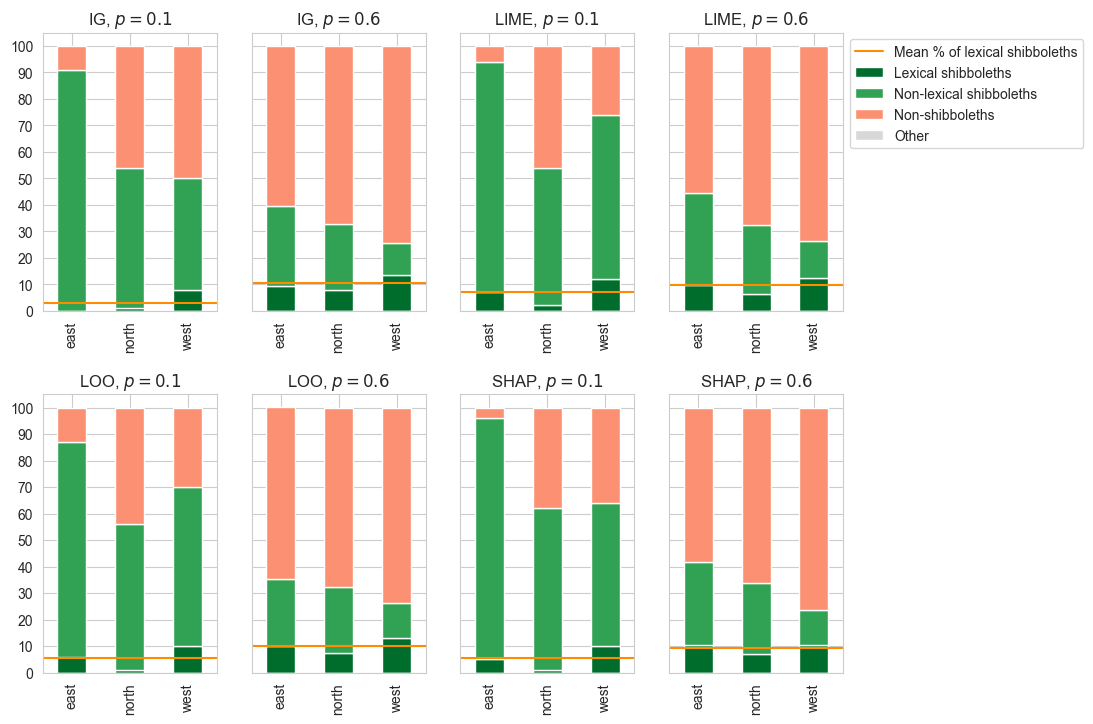

In [432]:
import pickle
with open('finnish_suomi24.pkl', 'wb') as f:
    pickle.dump(counts, f)

make_graphs_per_class(counts, 'finnish_suomi24')

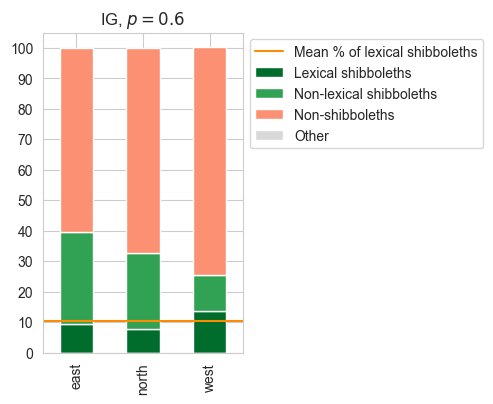

In [433]:
make_graphs_per_class({k:v for k,v in counts.items() if k == 'ig_0.6'}, 'select_finnish_suomi24')

In [434]:
def make_graphs_per_class(dict, ds):
    
    counts = dict
    outfile = ds + '_perclass.pdf'

    counts_df = pd.DataFrame.from_dict(counts, orient='index').stack().to_frame()
    counts_df[['Lexical', 'Non-lexical', 'Non shibboleth', 'Other', 'sum']] = counts_df.loc[:, 0].to_list()
    counts_df = counts_df.drop(columns=[counts_df.columns[0]]).drop(columns=['sum'])
    counts_df
    
    fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,8))
    
    idx = -1
    for i in range(0,2):
        for j in range(0,4):
            idx += 1  
            m = methods[idx]
            counts_df.loc[m].plot(kind='bar', stacked=True, title=m, colormap="summer", ax=axes[i,j], legend=False)
            mean = counts_df.loc[m]['Lexical'].mean()
           # if i == 1 and j == 3:
            axes[i,j].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
    
    axes[0, 0].set_yticks(range(0, 105, 10))
    axes[0, 0].set_ylim(0, 105)
    
    axes[1, 0].set_yticks(range(0, 105, 10))
    axes[1, 0].set_ylim(0, 105)
    
    ax=axes[1,3]
    handles, labels = ax.get_legend_handles_labels()
    #fig.legend(handles, labels, loc='upper center')
    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.2, -0.1), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

In [435]:
def make_graphs_per_class(dict, ds):
    
    counts = dict
    outfile = ds + '_perclass.pdf'

    counts_df = pd.DataFrame.from_dict(counts, orient='index').stack().to_frame()
    counts_df[['Lexical', 'Non-lexical', 'Non shibboleth', 'Other', 'sum']] = counts_df.loc[:, 0].to_list()
    counts_df = counts_df.drop(columns=[counts_df.columns[0]]).drop(columns=['sum'])
    counts_df
    
    fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,8))
    
    idx = -1
    for i in range(0,2):
        for j in range(0,4):
            idx += 1  
            m = methods[idx]
            counts_df.loc[m].plot(kind='bar', stacked=True, title=m, colormap="summer", ax=axes[i,j], legend=False)
            mean = counts_df.loc[m]['Lexical'].mean()
           # if i == 1 and j == 3:
            axes[i,j].axhline(mean, color='darkorange', linestyle='-', label='Mean % of lexical shibboleths')
    
    axes[0, 0].set_yticks(range(0, 105, 10))
    axes[0, 0].set_ylim(0, 105)
    
    axes[1, 0].set_yticks(range(0, 105, 10))
    axes[1, 0].set_ylim(0, 105)
    
    ax=axes[1,3]
    handles, labels = ax.get_legend_handles_labels()
    #fig.legend(handles, labels, loc='upper center')
    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.2, -0.1), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

# LEVELS OF LINGUISTIC STRUCTURE

In [436]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

def levels_to_pie(levels_df, selected_config, savename):
    my_df_ = levels_df.reset_index().sort_values(['feature', 'method', 'label']).pivot(index=['method', 'feature'], columns='label', values='count').reset_index()
    labels = levels_df.reset_index().label.unique()
    my_df_ = my_df_[my_df_['method'] == selected_config]

    print(my_df_)
    fig, axes = plt.subplots(nrows=1, ncols=len(labels), figsize=(4 * len(labels), 4))
    font_size = 16

    # always associate the same feature with the same color
    colors = {'lex': mpl.colormaps['Set2'].colors[0], 'morph': mpl.colormaps['Set2'].colors[1], 'phon': mpl.colormaps['Set2'].colors[2], 'spel': mpl.colormaps['Set2'].colors[3]}
    names = {'lex': 'Lexicon', 'morph': 'Morphology', 'phon': 'Phonetics', 'spel': 'Spelling'}
    cmap = ListedColormap([colors[x] for x in colors if x in my_df_["feature"].unique()])
    
    for idx, label in enumerate(sorted(labels)):
        display_df = my_df_[[label, 'feature']]
        display_df = display_df.set_index('feature')
        display_df.plot(
            kind='pie', 
            y=label, 
            colormap=cmap,
            legend=False,
            labels=None,
            ax=axes[idx],
            title=label,
            xlabel=None,
            ylabel=None,
            autopct=lambda p: '{:.1f}%'.format(round(p)) if p > 0 else '',
            textprops={'size': font_size}
        )
        axes[idx].set_ylabel(None)
        axes[idx].title.set_size(font_size)

    #legend
    patches = [mpatches.Patch(color=colors[c], label=names[c]) for c in colors]
    plt.legend(handles=patches, loc='center left', bbox_to_anchor=(1.1, 0.5), prop={'size': font_size})
    
    plt.tight_layout()
    fig.savefig(savename, bbox_inches='tight')

In [437]:
# not used, replaced by pie charts
def make_graphs_per_level(df, methods, classes, dataset):
    
    work_df = df
    methods = methods
    classes = classes
    ds = dataset
    dfs = []
    outfile = dataset + '_perlevel.pdf'

    fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,8))
        
    
    i = 0
    j = -1
    for m in methods:
        j += 1
        for c in classes:
            tmp = work_df.loc[(m, c)] ## indendted
            tmp['sum'] = tmp['count'].sum()
            tmp['perc'] = round(tmp['count'] / tmp['sum'] * 100, 1)
            tmp = tmp.drop(columns=['count', 'sum']).transpose()
            tmp['label'] = c
            tmp = tmp.set_index('label')
            dfs.append(tmp)

        df_to_plot = pd.concat(dfs).sort_index(axis=1)    
        print(df_to_plot)
        df_to_plot.plot(kind='bar', stacked=True, title = m, colormap='summer', ax = axes[i,j], legend=False)
    
        dfs = []
        
        if j == 3:
            i += 1
            j = -1
    
    axes[0, 0].set_yticks(range(0, 105, 10))
    axes[0, 0].set_ylim(0, 105)
    
    axes[1, 0].set_yticks(range(0, 105, 10))
    axes[1, 0].set_ylim(0, 105)
    
    axes[0,0].set_xlabel(None)
    axes[0,1].set_xlabel(None)
    axes[0,2].set_xlabel(None)
    axes[0,3].set_xlabel(None)
    axes[1,0].set_xlabel(None)
    axes[1,1].set_xlabel(None)
    axes[1,2].set_xlabel(None)
    axes[1,3].set_xlabel(None)
    
    ax=axes[0,2]
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.97, 0.7), bbox_transform=plt.gcf().transFigure)
    plt.subplots_adjust(left=0.1, right=0.9, 
                        top=0.9, bottom=0.1, 
                        wspace=0.2, hspace=0.3
                       )
    
    fig.figure.savefig(outfile, bbox_inches='tight')

In [438]:
def make_sel_graph_per_level(df, method, classes, dataset):
    
    work_df = df
    m = method
    classes = classes
    ds = dataset
    dfs = []
    outfile = dataset + '_perlevel_sel.barh.pdf'

    #fig  = plt.plot(figsize=(5,4))
    for c in classes:
        try: ## added
            tmp = work_df.loc[m, c] ## indented
            tmp['sum'] = tmp['count'].sum()
            tmp['perc'] = round(tmp['count'] / tmp['sum'] * 100, 1)
            tmp = tmp.drop(columns=['sum', 'perc']).transpose()
            tmp['label'] = c
            tmp = tmp.set_index('label')
            dfs.append(tmp)
        except KeyError:
            pass
    print(dfs)

    df_to_plot = pd.concat(dfs).sort_index(axis=1)
    g = df_to_plot.plot(
        kind='barh',
        xlim=(0, 100),
        stacked=True,
        color={'lex': '#006d2c', 'morph': '#31a354', 'phon': '#74c476', 'spel': '#a1d99b' },
        figsize=(5, 2),
        ylabel=None, 
        fontsize=16,
    )
    g.set(ylabel=None)
    g.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), labels=['Lexicon', 'Morphology', 'Phonetics', 'Spelling']).figure.savefig(outfile, bbox_inches='tight')
    
    
   # plt.set_yticks(range(0, 105, 10))
   # plt.set_ylim(0, 105)
    
#    axes[1, 0].set_yticks(range(0, 105, 10))
#    axes[1, 0].set_ylim(0, 105)
#    
#    axes[0,0].set_xlabel(None)
#    axes[0,1].set_xlabel(None)
#    axes[0,2].set_xlabel(None)
#    axes[0,3].set_xlabel(None)
#    axes[1,0].set_xlabel(None)
#    axes[1,1].set_xlabel(None)
#    axes[1,2].set_xlabel(None)
#    axes[1,3].set_xlabel(None)
    
#    ax=axes[0,2]
#    handles, labels = ax.get_legend_handles_labels()
#    plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.97, 0.7), bbox_transform=plt.gcf().transFigure)
#   # plt.subplots_adjust(left=0.1, right=0.9, 
#                        top=0.9, bottom=0.1, 
#                        wspace=0.2, hspace=0.3
#                       )
    
   # plt.figure.savefig(outfile, bbox_inches='tight')

### PREPARING BCMS SETIMES

In [439]:
bcms_setimes_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,method
file,,,,,,,,,,
list6,natjecateljskom,hr,0.241601,0.70,True,yes,lex,NaN,NaN,lime_0.6
list6,liječniku,hr,0.232991,0.67,True,yes,lex,NaN,jek,lime_0.6
list6,slijedili,hr,0.228810,0.69,True,no,phon,NaN,jek,lime_0.6
list6,natjecalo,hr,0.221181,0.66,True,yes,lex,NaN,NaN,lime_0.6
list6,strijelac,hr,0.211338,0.87,True,no,phon,NaN,jek,lime_0.6
...,...,...,...,...,...,...,...,...,...,...
list8,predsedavati,sr,0.362739,0.65,False,yes,phon,NaN,NaN,ig_0.6
list8,saopštavajući,sr,0.362684,0.92,False,yes,phon,NaN,NaN,ig_0.6
list8,evroatlantske,sr,0.362167,1.00,False,yes,phon,nonminimal,NaN,ig_0.6


In [440]:
f1 = bcms_setimes_df2[['feature', 'label']]
len(f1)

1600

In [441]:
f2 = bcms_setimes_df2[['feature2', 'label']].dropna()
f2['feature'] = f2['feature2']
f2 = f2.drop(columns=['feature2'])
len(f2)

99

In [442]:
feature_df = pd.concat([f1, f2])
feature_df = feature_df.reset_index(drop=False)
feature_df = feature_df[feature_df.feature.str.contains('phon|lex|morph-d|morph-f|spel')]
feature_df = feature_df.join(bcms_setimes_methods_df, how='left', on='file').drop(columns=('file'))
feature_df["feature"] = feature_df["feature"].str.replace("morph-d", "morph").replace("morph-f", "morph")
feature_df
# per method, per class

,feature,label,method
0,lex,hr,lime_0.6
1,lex,hr,lime_0.6
2,phon,hr,lime_0.6
3,lex,hr,lime_0.6
4,phon,hr,lime_0.6
...,...,...,...
1670,morph,hr,loo_0.1
1674,phon,sr,loo_0.1
1680,phon,hr,ig_0.6
1686,phon,hr,ig_0.6


In [443]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [444]:
classes = feature_df['label'].sort_values().unique()
classes

array(['hr', 'sr'], dtype=object)

In [445]:
bcms_setimes_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
bcms_setimes_levels_df

count
method   label feature       
ig_0.1   hr    lex         14
               morph        4
               phon        64
               spel         1
         sr    lex          7
               morph       17
               phon        27
               spel         2
ig_0.6   hr    lex         23
               morph        6
               phon        72
         sr    lex         14
               morph        8
               phon        73
               spel         1
lime_0.1 hr    lex          7
               morph       21
               phon        37
               spel         2
         sr    lex         15
               morph       29
               phon        38
lime_0.6 hr    lex         22
               morph       17
               phon        51
         sr    lex         15
               morph       22
               phon        48
               spel         1
loo_0.1  hr    lex          9
               morph       15
               phon        40
               spel         2
         sr    lex          5
               morph       13
               phon        20
loo_0.6  hr    lex         21
               morph       13
               phon        50
         sr    lex         12
               morph       10
               phon        47
               spel         1
shap_0.1 hr    lex         10
               morph       16
               phon        49
               spel         1
         sr    lex          5
               morph       10
               phon        19
               spel         1
shap_0.6 hr    lex         22
               morph       14
               phon        59
               spel         1
         sr    lex         11
               morph       13
               phon        43

label    method feature    hr    sr
8      lime_0.1     lex   7.0  15.0
9      lime_0.1   morph  21.0  29.0
10     lime_0.1    phon  37.0  38.0
11     lime_0.1    spel   2.0   NaN


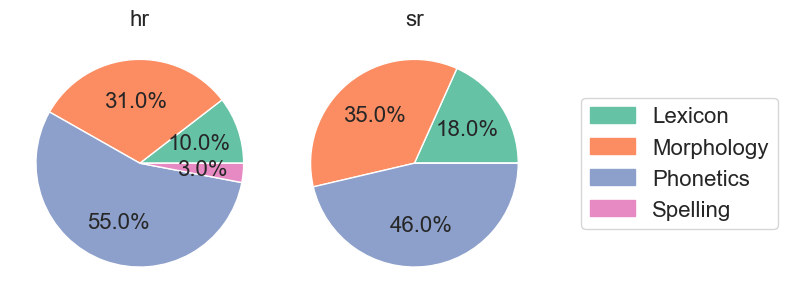

In [446]:
levels_to_pie(bcms_setimes_levels_df, 'lime_0.1', 'bcms_setimes_lime_0.1_pie.pdf')

In [447]:
bcms_setimes_levels_df.reset_index().label.unique()

array(['hr', 'sr'], dtype=object)

[feature  lex  morph  phon  spel
label                          
hr         7     21    37     2, feature  lex  morph  phon
label                    
sr        15     29    38]


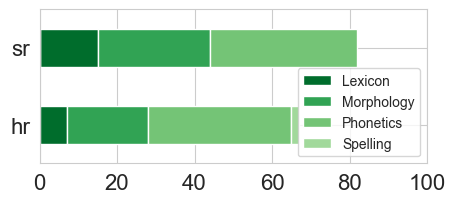

In [448]:
make_sel_graph_per_level(bcms_setimes_levels_df, 'lime_0.1', classes, 'bcms_setimes')

### PREPARING BCMS TWITTER

In [449]:
bcms_twitter_df2

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,method
file,,,,,,,,,,
list6,😎🌞<unk>☕️🍉,bs,1.525842,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,☕️😎,bs,1.430635,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,unk>😏,bs,1.371145,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,🙈<unk>🙊,bs,1.352293,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
list6,👍😏,bs,1.306748,0.104167,NaN,no,emoji,NaN,NaN,ig_0.1
...,...,...,...,...,...,...,...,...,...,...
list8,neizvesno,sr,0.611152,0.114583,NaN,yes,phon,NaN,NaN,lime_0.1
list8,osetiti,sr,0.610422,0.187500,NaN,yes,phon,NaN,NaN,lime_0.1
list8,pobedama,sr,0.608175,0.104167,NaN,yes,phon,NaN,NaN,lime_0.1


In this setup, it is possible to have non-shibboleths annotated for linguistic features

(a word can be marked, just not specific to a single variety)

In [450]:
f1 = bcms_twitter_df2[bcms_twitter_df2['shibboleth'] == 'yes'][['feature', 'label']]
f1

,feature,label
file,,
list6,lex,bs
list6,lex,bs
list6,lex,bs
list6,lex,bs
list6,lex,bs
...,...,...
list8,phon,sr
list8,phon,sr
list8,phon,sr


In [451]:
f2 = bcms_twitter_df2[bcms_twitter_df2['shibboleth'] ==  'yes'][['feature2', 'label']].dropna()
f2['feature'] = f2['feature2']
f2 = f2.drop(columns=['feature2'])
f2

,label,feature
file,,
list6,bs,spel
list6,bs,spel
list6,bs,nonminimal
list6,bs,nonminimal
list6,bs,nonminimal
...,...,...
list8,me,spel
list8,sr,morph-f
list8,sr,nonminimal


In [452]:
feature_df = pd.concat([f1, f2])
#feature_df['file'] = feature_df.index
feature_df = feature_df.reset_index() #.drop(columns=('index'))
feature_df = feature_df[feature_df.feature.str.contains('phon|lex|morph-d|morph-f|spel')]
feature_df = feature_df.join(bcms_setimes_methods_df, how='left', on='file').drop(columns=('file'))
feature_df["feature"] = feature_df["feature"].str.replace("morph-d", "morph").replace("morph-f", "morph")
feature_df

,feature,label,method
0,lex,bs,lime_0.6
1,lex,bs,lime_0.6
2,lex,bs,lime_0.6
3,lex,bs,lime_0.6
4,lex,bs,lime_0.6
...,...,...,...
1024,spel,me,ig_0.6
1025,spel,me,ig_0.6
1026,spel,me,ig_0.6
1027,morph,sr,ig_0.6


In [453]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [454]:
classes = feature_df['label'].sort_values().unique()
classes

array(['bs', 'hr', 'me', 'sr'], dtype=object)

In [455]:
bcms_twitter_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
bcms_twitter_levels_df

count
method   label feature       
ig_0.1   bs    lex          3
               spel         2
         hr    lex          5
               morph        2
               phon         6
...                       ...
shap_0.6 me    lex          1
               phon        10
               spel         4
         sr    morph        1
               phon        87

[80 rows x 1 columns]

label    method feature   bs    hr    me    sr
8      lime_0.1     lex  6.0  10.0   NaN   1.0
9      lime_0.1   morph  NaN   3.0   NaN   NaN
10     lime_0.1    phon  NaN   7.0  13.0  91.0
11     lime_0.1    spel  2.0   NaN   2.0   NaN


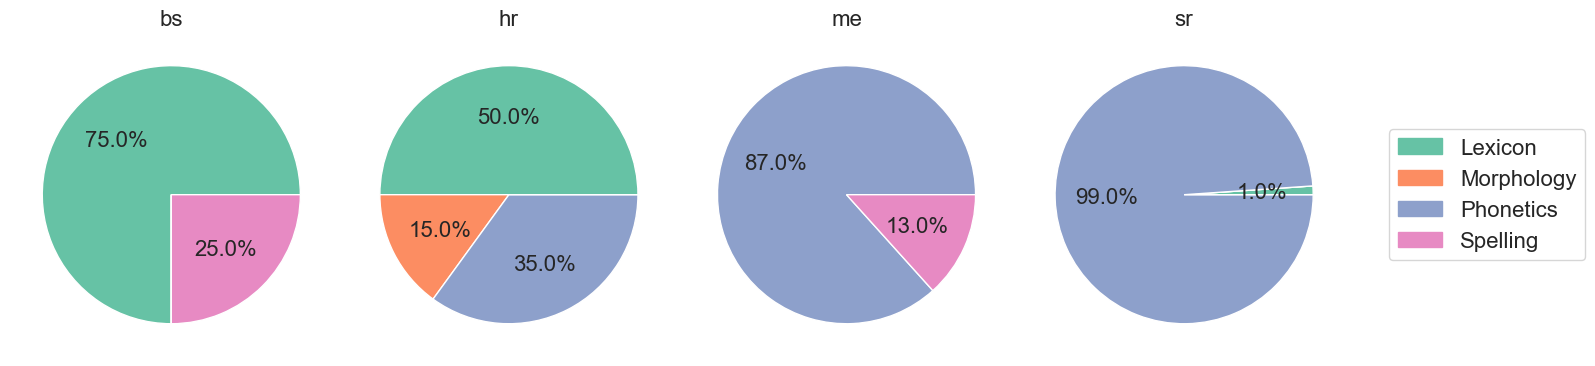

In [456]:
levels_to_pie(bcms_twitter_levels_df, 'lime_0.1', 'bcms_twitter_lime_0.1_pie.pdf')

In [457]:
# make_graphs_per_level(bcms_twitter_levels_df, methods, classes, 'bcms_twitter')

[feature  lex  spel
label             
bs         6     2, feature  lex  morph  phon
label                    
hr        10      3     7, feature  phon  spel
label              
me         13     2, feature  lex  phon
label             
sr         1    91]


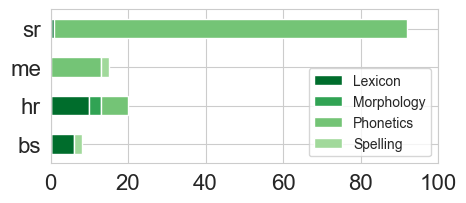

In [458]:
make_sel_graph_per_level(bcms_twitter_levels_df, 'lime_0.1', classes, 'bcms_twitter')

## PREPARING FINNISH

In [459]:
finnish_suomi24_df2

,Unnamed: 0,token,label,score,selection_freq,category,lex_other_not,method
file,,,,,,,,
list8,0,täötyy,east,0.863224,0.101010,phon,other,shap_0.1
list8,1,pahimoelleen,east,0.847876,0.101010,phon,other,shap_0.1
list8,2,sullakii,east,0.826737,0.202020,morph,other,shap_0.1
list8,3,paekkaan,east,0.811686,0.101010,phon,other,shap_0.1
list8,4,piästii,east,0.804127,0.101010,phon,other,shap_0.1
...,...,...,...,...,...,...,...,...
list7,295,varovainen,west,0.258827,0.101010,not,not,ig_0.1
list7,296,miä,west,0.258084,0.161616,lex,lex,ig_0.1
list7,297,nää,west,0.257057,0.191919,not,not,ig_0.1


In [460]:
feature_df = finnish_suomi24_df2[(finnish_suomi24_df2['lex_other_not'] == 'lex') | (finnish_suomi24_df2['lex_other_not'] == 'other')][['category', 'label', 'method']]
feature_df = feature_df[feature_df.category.str.contains('morph|lex|phon')]
feature_df

,category,label,method
file,,,
list8,phon,east,shap_0.1
list8,phon,east,shap_0.1
list8,morph,east,shap_0.1
list8,phon,east,shap_0.1
list8,phon,east,shap_0.1
...,...,...,...
list7,lex,west,ig_0.1
list7,lex,west,ig_0.1
list7,phon,west,ig_0.1


In [461]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [462]:
classes = feature_df['label'].sort_values().unique()
classes

array(['east', 'north', 'west'], dtype=object)

In [463]:
finnish_suomi24_levels_df = feature_df.rename(columns={'category': 'feature'}).groupby(['method', 'label', 'feature']).size().to_frame(name='count')
finnish_suomi24_levels_df

count
method   label feature       
ig_0.1   east  morph       24
               phon        67
         north lex          1
               morph       22
               phon        27
...                       ...
shap_0.6 north morph        8
               phon        11
         west  lex          7
               morph        1
               phon         8

[71 rows x 1 columns]

In [464]:
#make_graphs_per_level(finnish_suomi24_levels_df, methods, classes, 'finnish_suomi24-test')

[feature  lex  morph  phon
label                    
east       6      6    13, feature  lex  morph  phon
label                    
north      5      8     8, feature  lex  morph  phon
label                    
west       8      1     6]


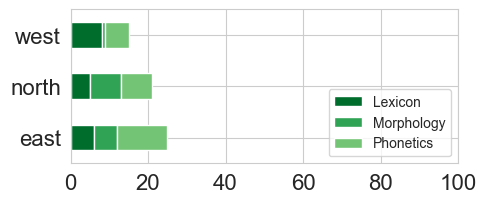

In [465]:
make_sel_graph_per_level(finnish_suomi24_levels_df, 'ig_0.6', classes, 'finnish_suomi24')

label  method feature  east  north  west
3      ig_0.6     lex   6.0    5.0   8.0
4      ig_0.6   morph   6.0    8.0   1.0
5      ig_0.6    phon  13.0    8.0   6.0


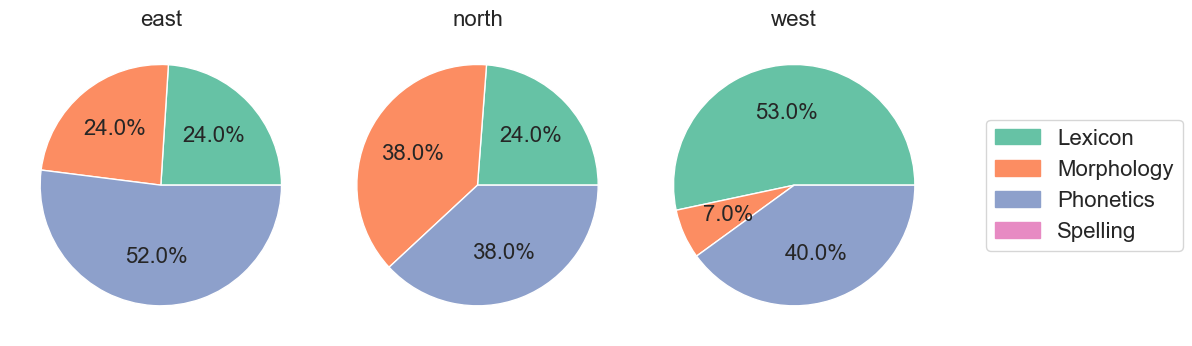

In [466]:
levels_to_pie(finnish_suomi24_levels_df, 'ig_0.6', 'finnish_suomi24_ig_0.6_pie.pdf')


### PREPARING GREEK 

In [467]:
greek_dialects_df2['feature'].sort_values().unique()

array(['I', 'Lex', 'Morph', 'NE', 'Other', 'Phon', 'Spell', 'Unmarked',
       'ΝΕ'], dtype=object)

In [468]:
feature_df = greek_dialects_df2[['feature', 'label', 'method']]
feature_df = feature_df[feature_df.feature.str.contains('Morph|Lex|Phon|Spell')]
feature_df['feature'] =  feature_df['feature'].str.lower().replace("spell", "spel")
feature_df

,feature,label,method
file,,,
list6,lex,cre,ig_0.1
list6,morph,cre,ig_0.1
list6,phon,cre,ig_0.1
list6,lex,cre,ig_0.1
list6,lex,cre,ig_0.1
...,...,...,...
list8,morph,pon,lime_0.1
list8,morph,pon,lime_0.1
list8,lex,pon,lime_0.1


In [469]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [470]:
classes = feature_df['label'].sort_values().unique()
classes

array(['cre', 'cyp', 'nor', 'pon'], dtype=object)

In [471]:
greek_dialects_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
greek_dialects_levels_df

count
method   label feature       
ig_0.1   cre   lex         25
               morph       14
               phon         9
         cyp   lex          6
               morph        2
...                       ...
shap_0.6 nor   morph       13
               phon        38
         pon   lex          9
               morph       13
               phon         8

[96 rows x 1 columns]

label  method feature   cre   cyp   nor   pon
3      ig_0.6     lex  25.0   6.0  10.0  33.0
4      ig_0.6   morph  17.0   4.0  18.0  23.0
5      ig_0.6    phon  19.0  25.0  38.0  16.0
6      ig_0.6    spel   1.0   NaN   NaN   NaN


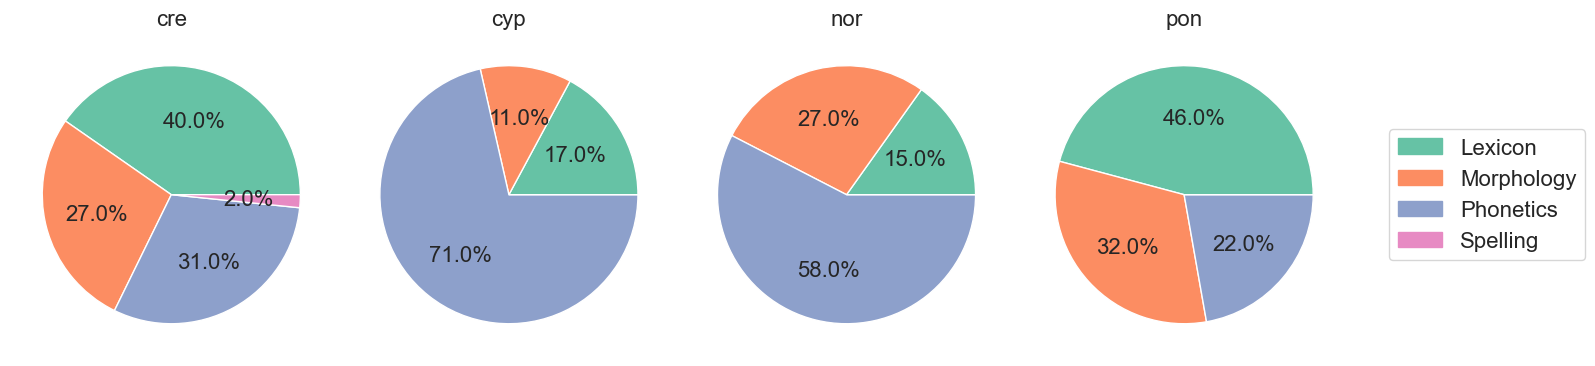

In [472]:
levels_to_pie(greek_dialects_levels_df, 'ig_0.6', 'greek_dialects_ig_0.6_pie.pdf')

[feature  lex  morph  phon  spel
label                          
cre       25     17    19     1, feature  lex  morph  phon
label                    
cyp        6      4    25, feature  lex  morph  phon
label                    
nor       10     18    38, feature  lex  morph  phon
label                    
pon       33     23    16]


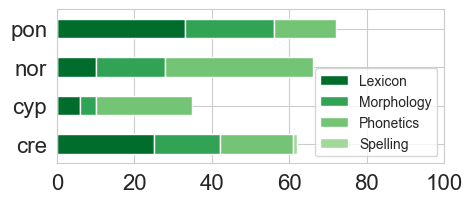

In [473]:
make_sel_graph_per_level(greek_dialects_levels_df, 'ig_0.6', classes, 'greek_dialects')

### PREPARING JODEL

In [474]:
german_jodel_df2[german_jodel_df2['shibboleth'] == 'yes']['code'].sort_values().unique()

array(['lex', 'morph', 'other', 'phon', 'spell'], dtype=object)

In [475]:
feature_df = german_jodel_df2[german_jodel_df2['shibboleth'] == 'yes'][['label', 'method', 'code']]
feature_df = feature_df[feature_df.code.str.contains('morph|lex|phon|spell')]
feature_df['code'] =  feature_df['code'].str.replace("spell", "spel")
feature_df = feature_df.rename(columns={'code': 'feature'})
feature_df

,label,method,feature
file,,,
list6,at,shap_0.1,morph
list6,at,shap_0.1,morph
list6,at,shap_0.1,morph
list6,at,shap_0.1,lex
list6,at,shap_0.1,morph
...,...,...,...
list8,ch,loo_0.6,phon
list8,ch,loo_0.6,morph
list8,ch,loo_0.6,phon


In [476]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [477]:
classes = feature_df['label'].sort_values().unique()
classes

array(['at', 'ch', 'de_n', 'de_s'], dtype=object)

In [478]:
german_jodel_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
german_jodel_levels_df

count
method   label feature       
ig_0.1   at    lex         14
               morph        7
               phon         4
         ch    lex         18
               morph        4
               phon        38
         de_n  lex          2
         de_s  lex         23
ig_0.6   at    lex          8
               morph        5
         ch    lex         10
               morph       15
               phon        49
         de_s  lex          2
lime_0.1 at    lex         16
               morph       16
               phon         1
         ch    lex         13
               morph       13
               phon        27
         de_n  lex          2
         de_s  lex         13
lime_0.6 at    lex          5
               morph        5
         ch    lex         16
               morph       18
               phon        27
         de_s  lex          2
loo_0.1  at    lex         11
               morph       15
               phon         2
         ch    lex          8
               morph       14
               phon        27
               spel         2
         de_s  lex         10
loo_0.6  at    lex          6
               morph        6
         ch    lex         13
               morph       14
               phon        21
               spel         1
         de_s  lex          2
shap_0.1 at    lex         15
               morph       12
               phon         2
         ch    lex         16
               morph       10
               phon        33
               spel         2
         de_s  lex          9
shap_0.6 at    lex          4
               morph        7
               phon         1
         ch    lex         14
               morph       20
               phon        31
         de_s  lex          1

label  method feature    at    ch  de_n  de_s
0      ig_0.1     lex  14.0  18.0   2.0  23.0
1      ig_0.1   morph   7.0   4.0   NaN   NaN
2      ig_0.1    phon   4.0  38.0   NaN   NaN


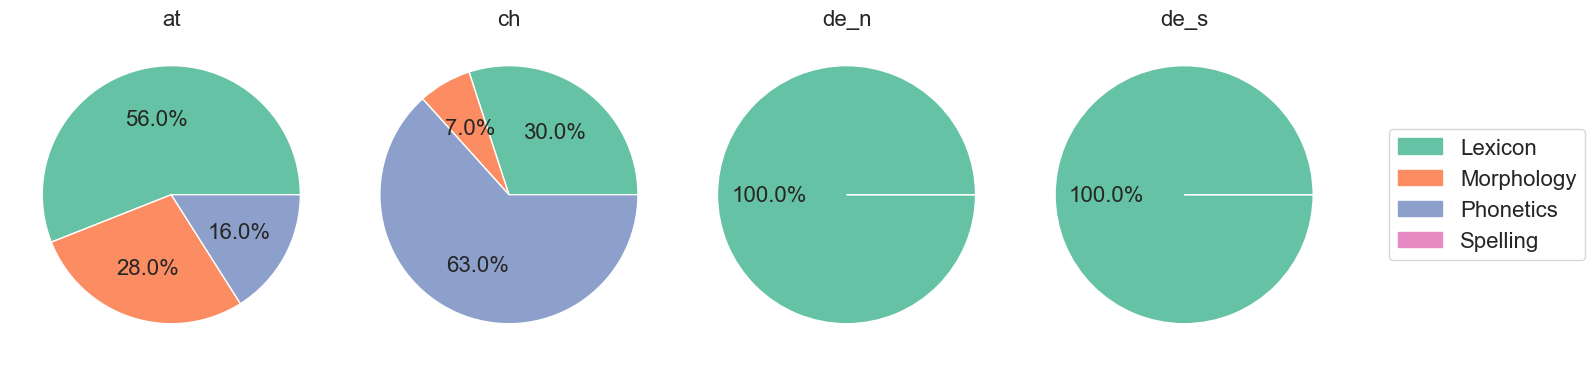

In [479]:
levels_to_pie(german_jodel_levels_df, 'ig_0.1', 'german_jodel_ig_0.1_pie.pdf')

[feature  lex  morph  phon
label                    
at        14      7     4, feature  lex  morph  phon
label                    
ch        18      4    38, feature  lex
label       
de_n       2, feature  lex
label       
de_s      23]


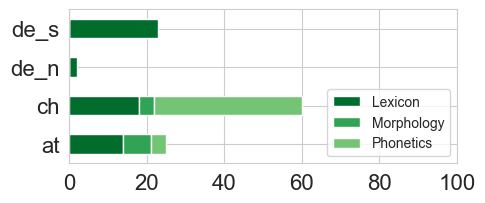

In [480]:
make_sel_graph_per_level(german_jodel_levels_df, 'ig_0.1', classes, 'german_jodel')

### PREPARING SLIDE

In [481]:
scandinavian_slide_df2

,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,method
file,,,,,,,,,,,,,,,,,,,,
list3,0,ydmyghed,da,1.008674,0.10,False,NaN,ydmykhet,audmykt,ödmjukhet,False,False,True,True,False,False,False,False,True,shap_0.1
list3,1,styrtregnede,da,1.000334,0.10,False,NaN,styrtregnet,styrtregna,NaN,False,False,True,False,False,False,False,False,True,shap_0.1
list3,2,broderede,da,1.000113,0.10,False,NaN,broderte,NaN,broderade,False,False,True,False,False,False,False,False,True,shap_0.1
list3,3,åbningsudsalg,da,0.999946,0.10,False,NaN,åpningssalg?,NaN,öppningsrea?,False,False,False,False,False,False,True,False,False,shap_0.1
list3,4,orddelingsfejl,da,0.999925,0.10,False,NaN,orddelingsfeil,NaN,NaN,False,False,False,True,False,False,False,False,True,shap_0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
list8,395,lämnade,sv,0.155722,0.98,False,efterlod,etterlot,NaN,NaN,False,False,False,False,False,False,True,False,False,lime_0.6
list8,396,färdiga,sv,0.154972,0.75,False,NaN,ferdige,ferdige,NaN,False,False,False,True,False,False,False,False,True,lime_0.6
list8,397,väntar,sv,0.154830,1.00,False,venter,venter,ventar,NaN,False,False,True,True,False,False,False,False,True,lime_0.6


In [482]:
feature_df = scandinavian_slide_df2[(scandinavian_slide_df2['LexShib'] == True) | \
                                    (scandinavian_slide_df2['NonLexShib'] == True)][['Morph', 'Phon_Spell', 'LexShib', 'method', 'label']]
feature_df['LexShib'] = feature_df['LexShib'].replace(True, 'Lex')
feature_df['Morph'] = feature_df['Morph'].replace(True, 'Morph')
feature_df['Phon_Spell'] = feature_df['Phon_Spell'].replace(True, 'Phon_Spell')
feature_df

,Morph,Phon_Spell,LexShib,method,label
file,,,,,
list3,Morph,Phon_Spell,False,shap_0.1,da
list3,Morph,False,False,shap_0.1,da
list3,Morph,False,False,shap_0.1,da
list3,False,False,Lex,shap_0.1,da
list3,False,Phon_Spell,False,shap_0.1,da
...,...,...,...,...,...
list8,False,False,Lex,lime_0.6,sv
list8,False,Phon_Spell,False,lime_0.6,sv
list8,Morph,Phon_Spell,False,lime_0.6,sv


In [483]:
tmp1 = feature_df[['Morph', 'method', 'label']]
tmp1['feature'] = tmp1['Morph']
tmp1 = tmp1.drop(columns=['Morph'])
tmp1

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/2651079599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['feature'] = tmp1['Morph']


,method,label,feature
file,,,
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
list3,shap_0.1,da,False
list3,shap_0.1,da,False
...,...,...,...
list8,lime_0.6,sv,False
list8,lime_0.6,sv,False
list8,lime_0.6,sv,Morph


In [484]:
tmp2 = feature_df[['LexShib', 'method', 'label']]
tmp2['feature'] = tmp2['LexShib']
tmp2 = tmp2.drop(columns=['LexShib'])
tmp2

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/2370939929.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['feature'] = tmp2['LexShib']


,method,label,feature
file,,,
list3,shap_0.1,da,False
list3,shap_0.1,da,False
list3,shap_0.1,da,False
list3,shap_0.1,da,Lex
list3,shap_0.1,da,False
...,...,...,...
list8,lime_0.6,sv,Lex
list8,lime_0.6,sv,False
list8,lime_0.6,sv,False


In [485]:
tmp3 = feature_df[['Phon_Spell', 'method', 'label']]
tmp3['feature'] = tmp3['Phon_Spell']
tmp3 = tmp3.drop(columns=['Phon_Spell'])
tmp3

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_67541/2819609312.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp3['feature'] = tmp3['Phon_Spell']


,method,label,feature
file,,,
list3,shap_0.1,da,Phon_Spell
list3,shap_0.1,da,False
list3,shap_0.1,da,False
list3,shap_0.1,da,False
list3,shap_0.1,da,Phon_Spell
...,...,...,...
list8,lime_0.6,sv,False
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell


In [486]:
feature_df = pd.concat([tmp1, tmp2, tmp3])
feature_df = feature_df[feature_df['feature'] != False]
feature_df

,method,label,feature
file,,,
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
list3,shap_0.1,da,Morph
...,...,...,...
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell
list8,lime_0.6,sv,Phon_Spell


In [487]:
methods = feature_df['method'].sort_values().unique()
methods

array(['ig_0.1', 'ig_0.6', 'lime_0.1', 'lime_0.6', 'loo_0.1', 'loo_0.6',
       'shap_0.1', 'shap_0.6'], dtype=object)

In [488]:
classes = feature_df['label'].sort_values().unique()
classes

array(['da', 'nb', 'nn', 'sv'], dtype=object)

In [489]:
scandinavian_slide_levels_df = feature_df.groupby(['method', 'label', 'feature']).size().to_frame(name='count')
scandinavian_slide_levels_df

count
method   label feature          
ig_0.1   da    Lex            24
               Morph          14
               Phon_Spell     48
         nb    Lex             6
               Morph          29
...                          ...
shap_0.6 nn    Morph          13
               Phon_Spell     17
         sv    Lex            25
               Morph          31
               Phon_Spell     55

[96 rows x 1 columns]

In [490]:
#make_graphs_per_level(scandinavian_slide_levels_df, methods, classes, 'scandinavian_slide')

In [491]:

bcms_twitter_levels_df.to_csv('bcms_levels.csv', index=False)
finnish_suomi24_levels_df.to_csv('bcms_levels.csv', index=False)
greek_dialects_levels_df.to_csv('bcms_levels.csv', index=False)
german_jodel_levels_df.to_csv('bcms_levels.csv', index=False)
